In [1]:
from typing import Dict, List
from model_ranking import (
    get_classification_consistency_results,
    get_classification_performance_results,
    plot_performance_vs_transfer_metric_multi_target,
    ClassificationPredicitonLoadConfig,
    to_target_transfer_correlations,
    correlation_table,
    augmentation_type
)

INFO: P [MainThread] 2025-10-20 09:33:06,865 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
source_models=[
    "DenseNet121",
    "MobileNetV2",
    "MobileNetV3",
    "ResNet50",
    "ResNet18",
    "VGG16",
]
sources = ["EPFL", "Hmito", "Rmito"]
targets = ["EPFL", "Hmito", "Rmito"]
consis_key = "HD_consis"
performance_key = "f1_score"
base_path = "/g/kreshuk/talks/sampled_features/classification/mitochondria"
perturbations: Dict[augmentation_type, List[str]] = {
   "Gauss": ["a001-005", "a005-01", "a01-015", "a015-02", "a02-025"],
}

100%|██████████| 5/5 [00:00<00:00,  9.02it/s]


Processing: Gauss_Consistency_a001-005
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


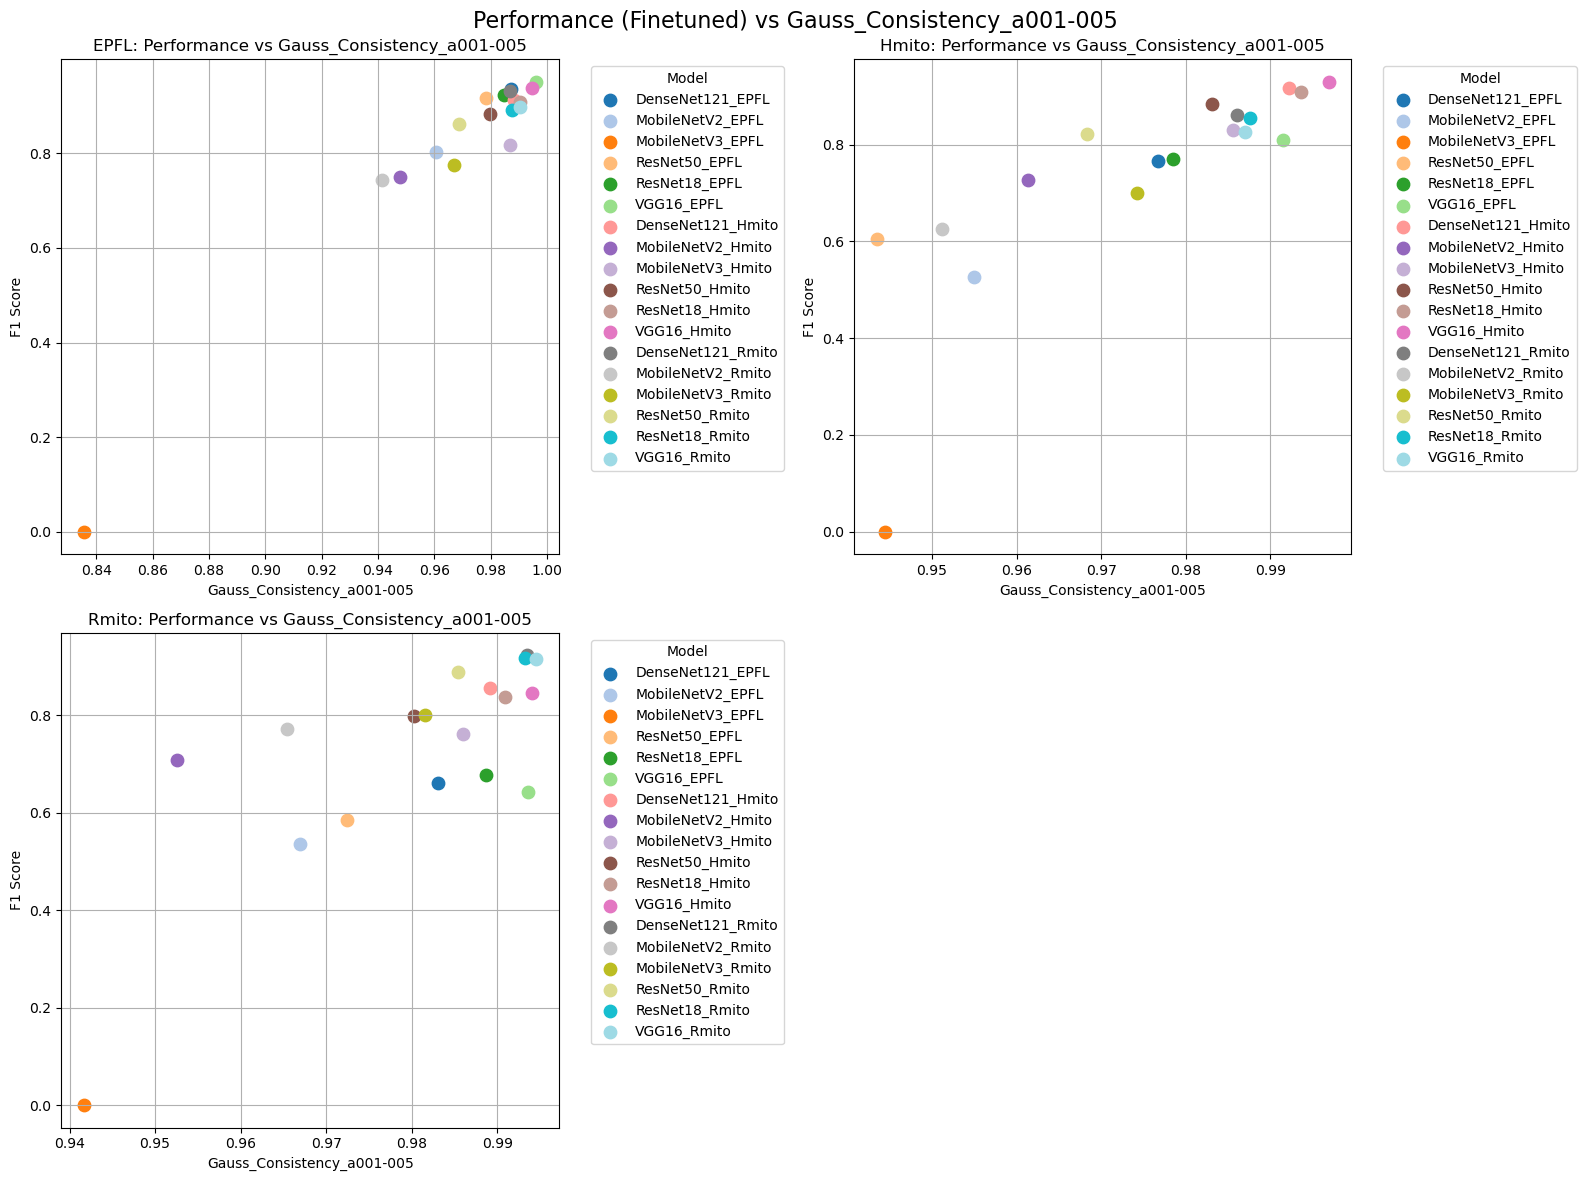

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.98      0.0   0.79        0.00  0.67      0.0
     Hmito    0.80      0.0   0.89        0.00  0.73      0.0
     Rmito    0.76      0.0   0.63        0.01  0.49      0.0
Processing: Gauss_Consistency_a005-01
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


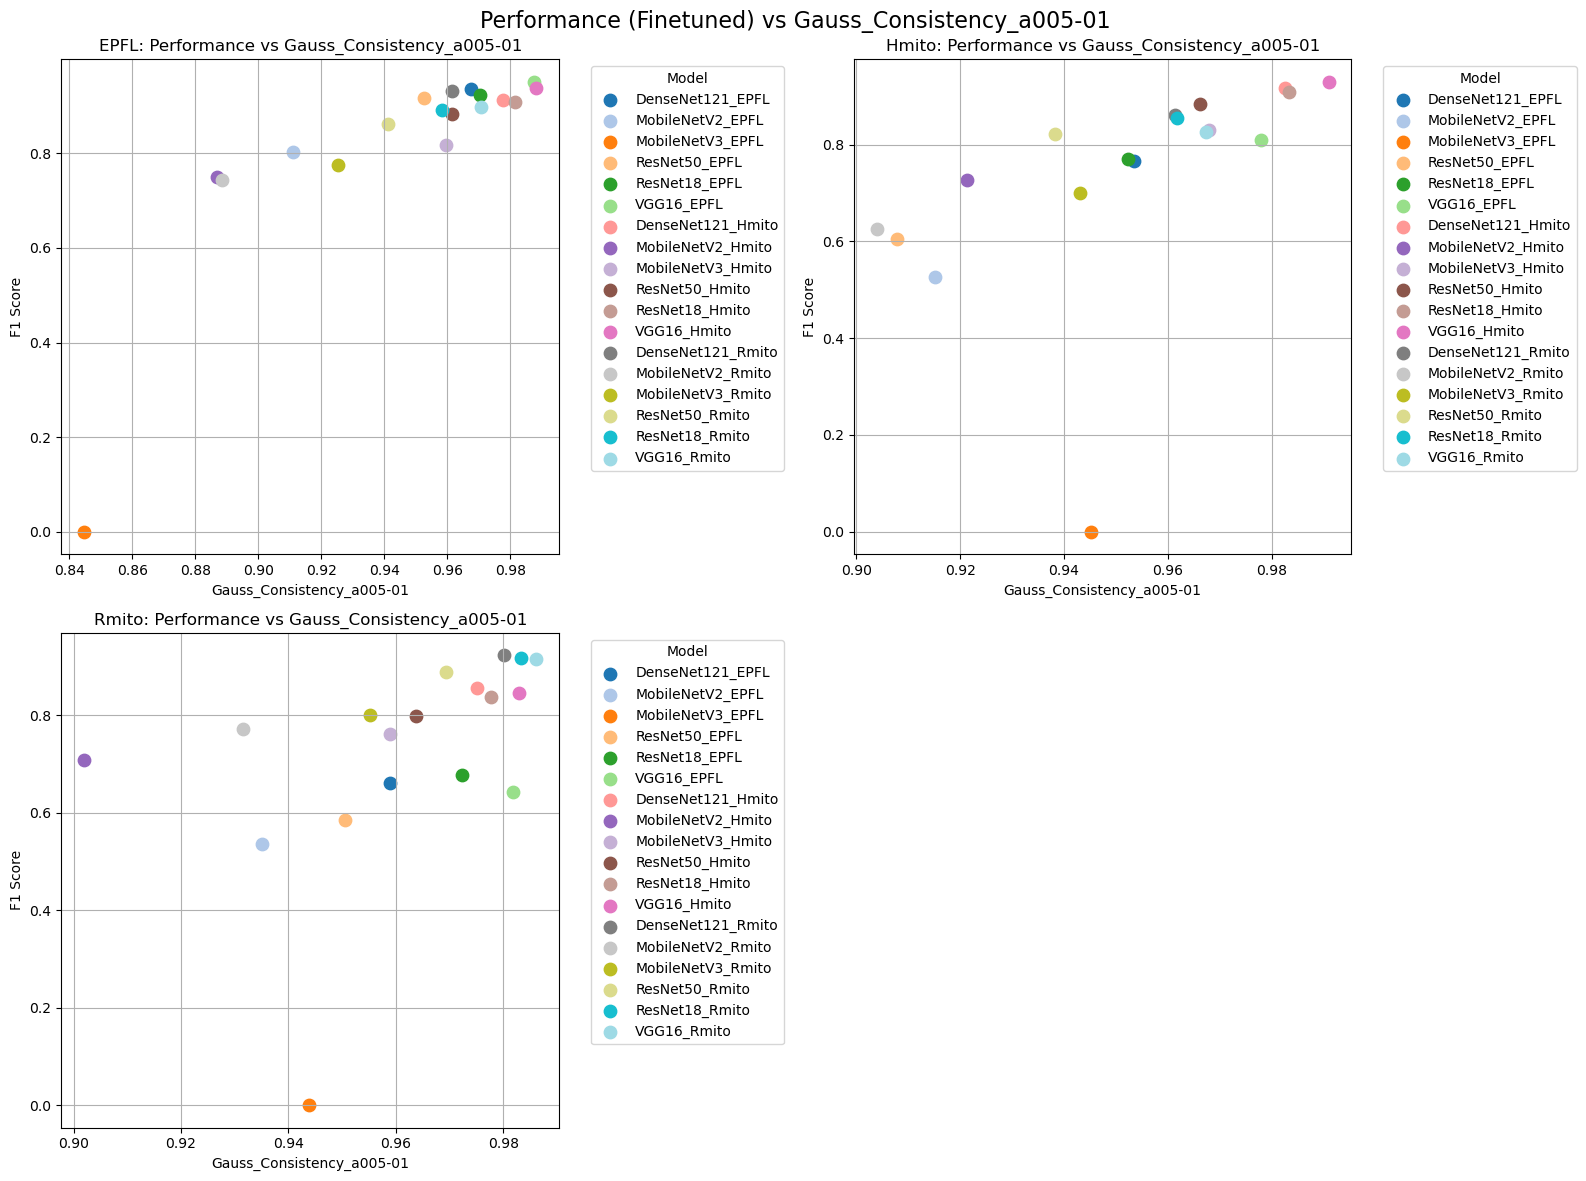

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.82     0.00   0.84        0.00  0.67      0.0
     Hmito    0.52     0.03   0.84        0.00  0.63      0.0
     Rmito    0.44     0.06   0.65        0.01  0.49      0.0
Processing: Gauss_Consistency_a01-015
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


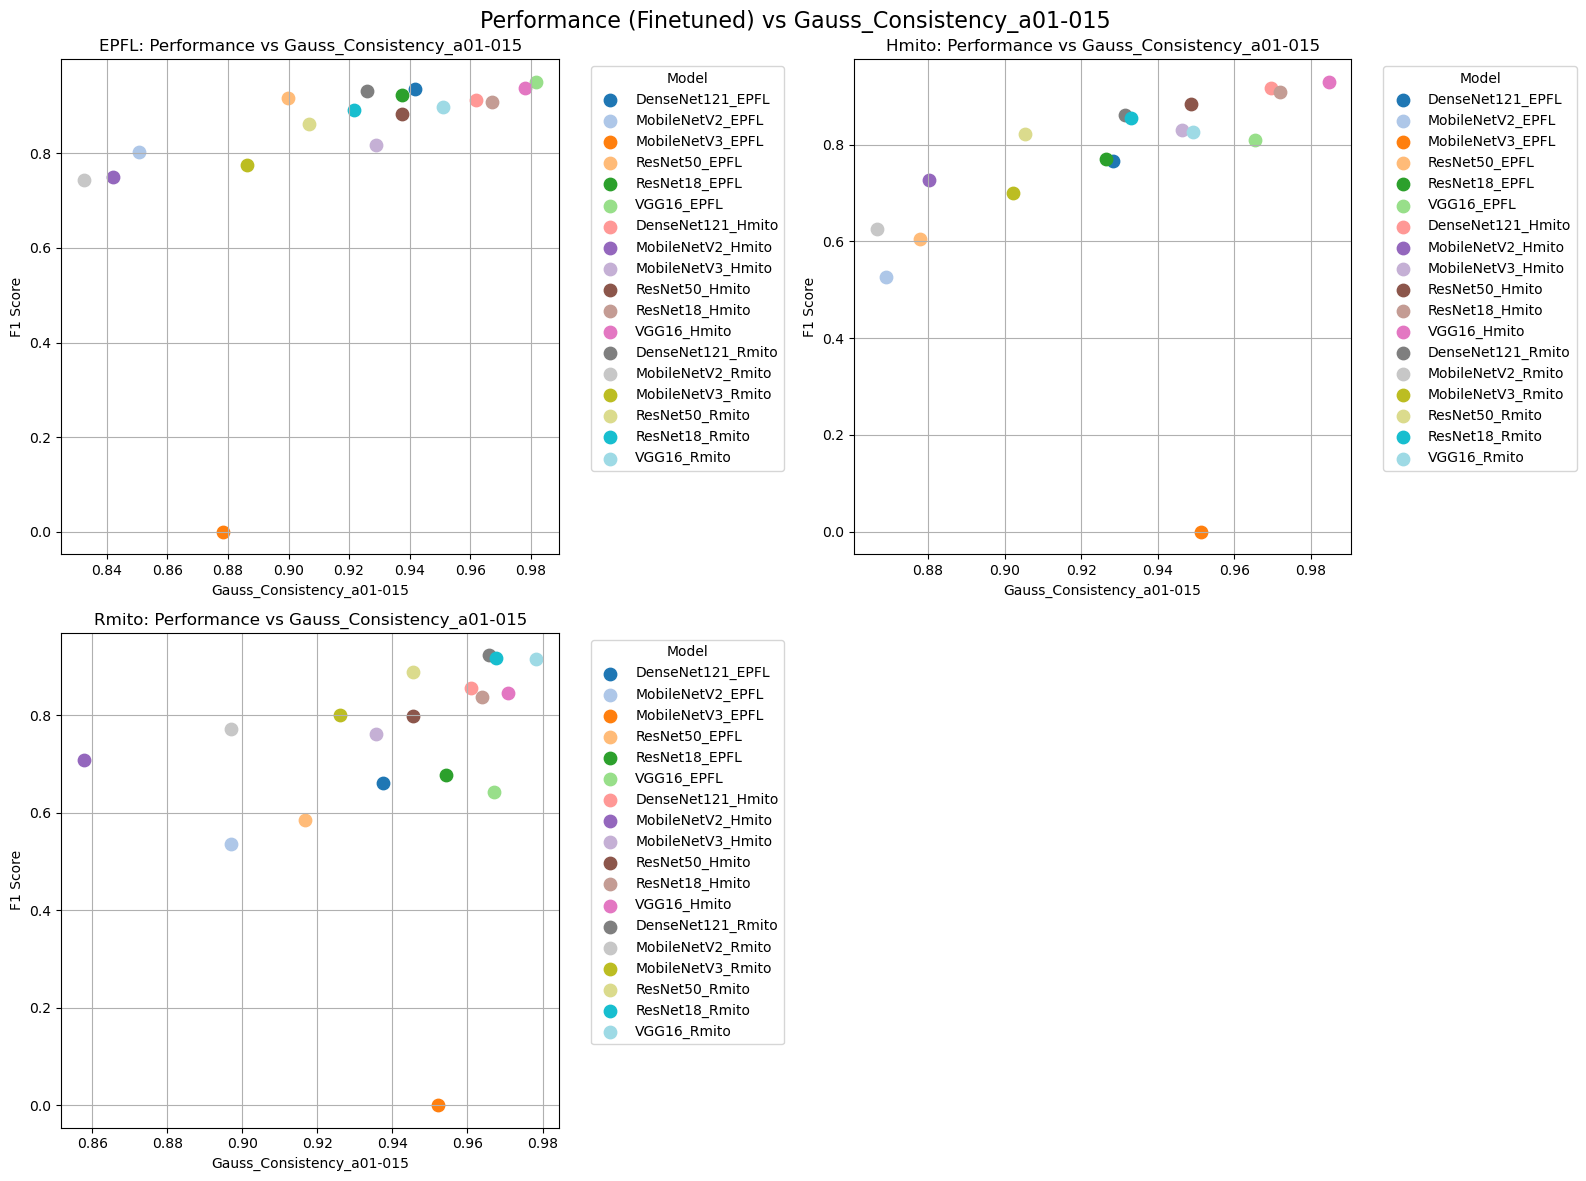

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.47     0.05   0.80        0.00  0.65     0.00
     Hmito    0.33     0.19   0.70        0.00  0.57     0.00
     Rmito    0.22     0.37   0.55        0.01  0.39     0.02
Processing: Gauss_Consistency_a015-02
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


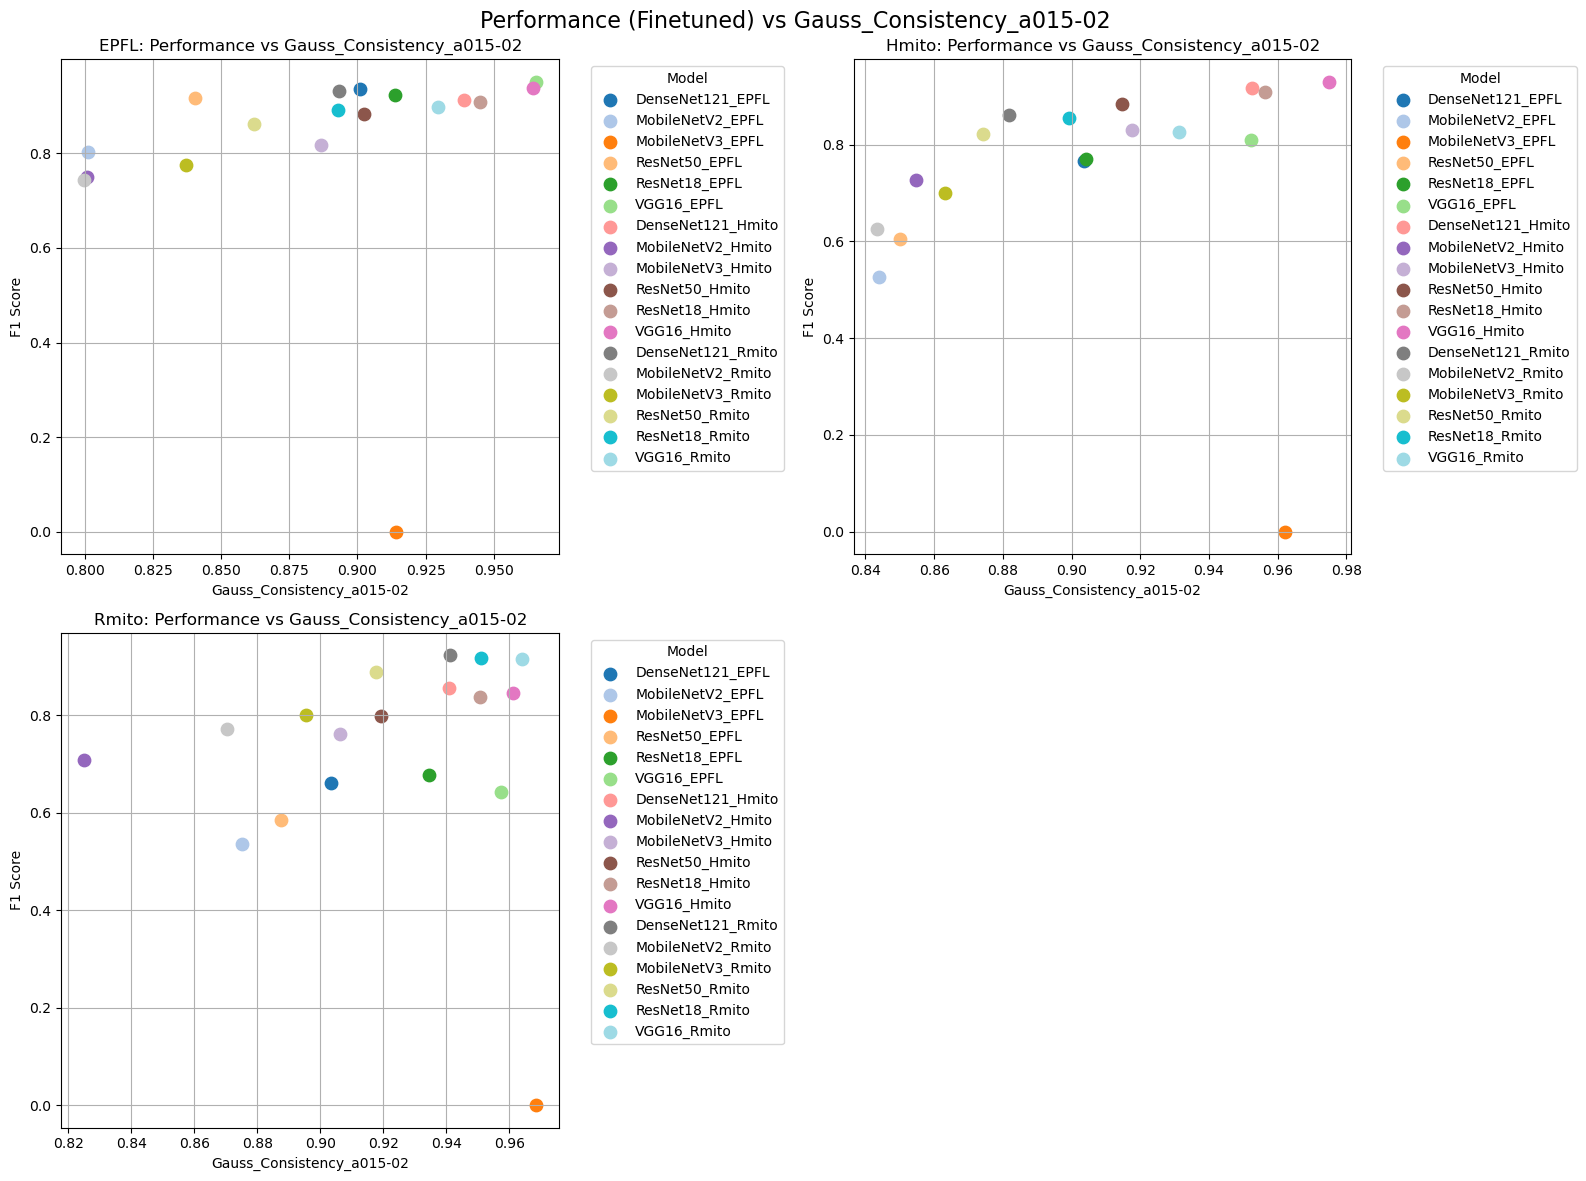

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.14     0.58   0.64        0.01  0.53     0.00
     Hmito    0.12     0.63   0.57        0.02  0.48     0.01
     Rmito    0.01     0.97   0.31        0.20  0.25     0.13
Processing: Gauss_Consistency_a02-025
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


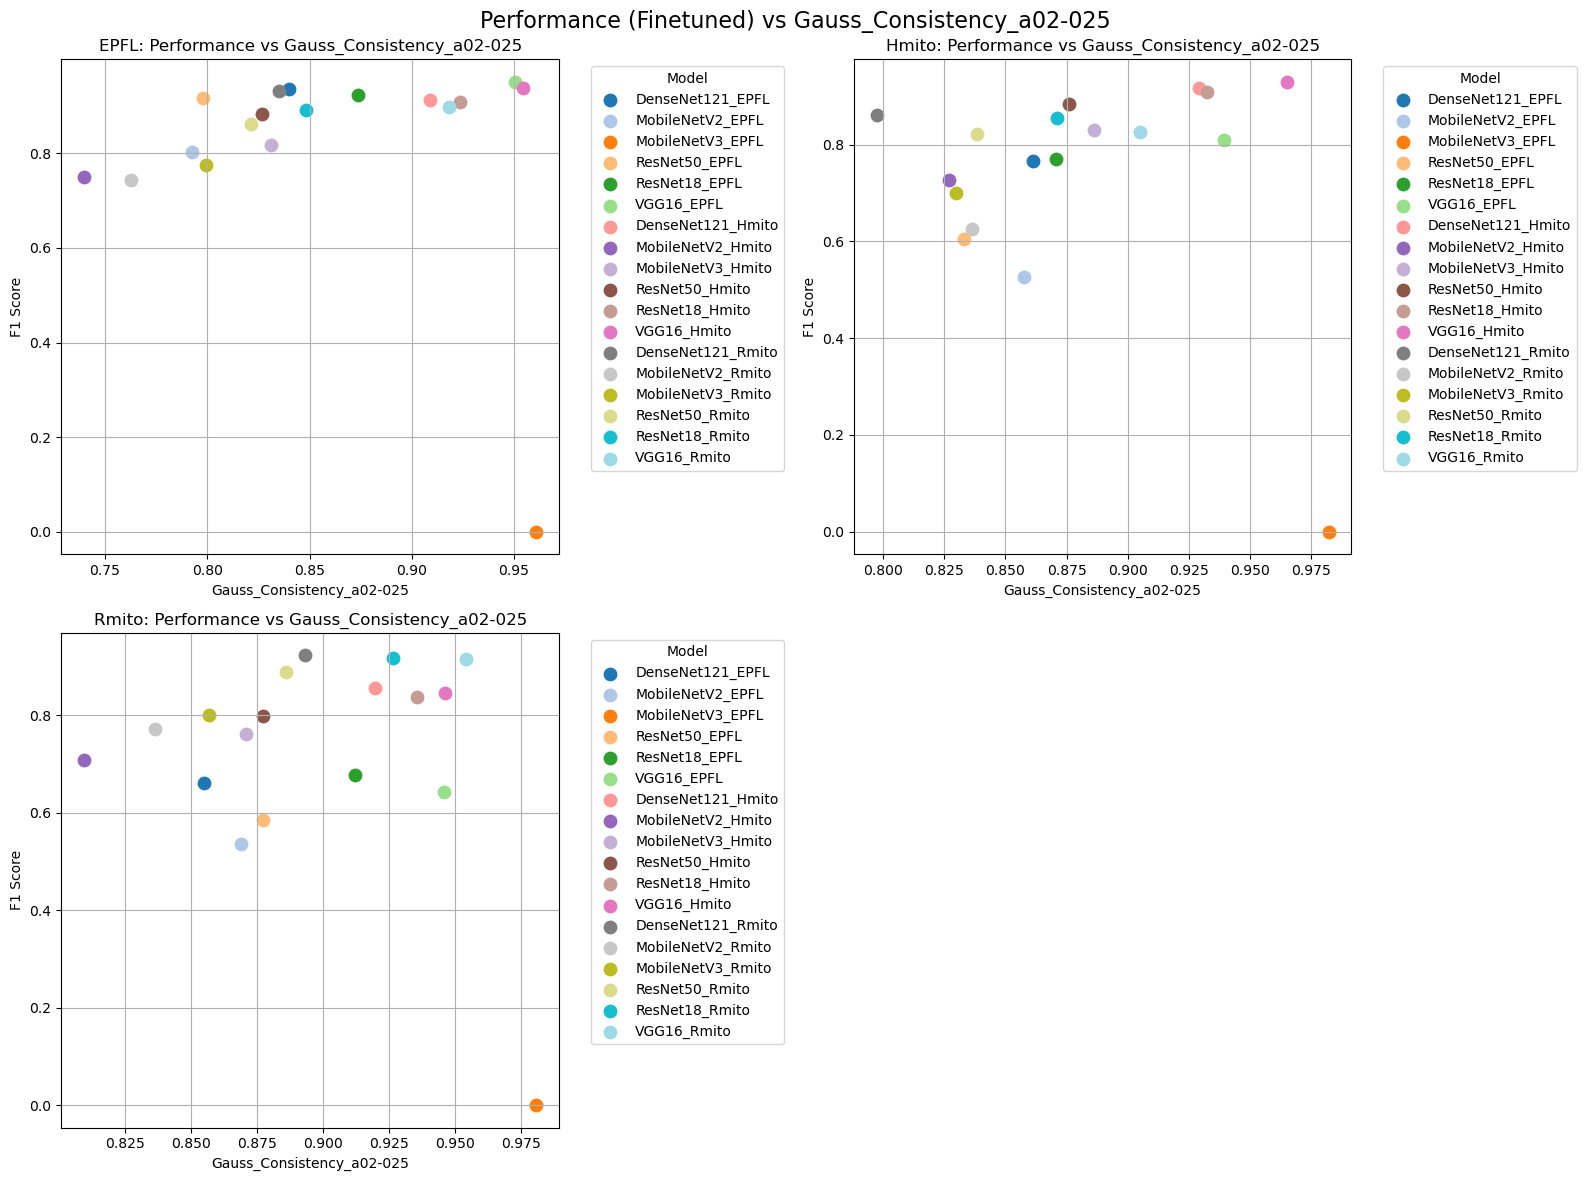

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL    -0.16     0.53   0.48        0.04  0.41     0.02
     Hmito   -0.17     0.51   0.37        0.16  0.29     0.10
     Rmito   -0.20     0.42   0.22        0.37  0.16     0.36


In [4]:
models: List[str] = []
for source in sources:
    models.extend([f"{model}_{source}" for model in source_models])
cfg = ClassificationPredicitonLoadConfig(
    source=models,
    target=targets,
    base_path=base_path,
    perturbations=perturbations,
)
consis_results = get_classification_consistency_results(cfg, consis_key)
performance_results = get_classification_performance_results(cfg, performance_key)

for p_str in perturbations["Gauss"]:
    consis_scores = consis_results["Gauss"][p_str]
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=performance_results,
        transfer_scores=consis_scores,
        transfer_metric=f"Gauss_Consistency_{p_str}",
        finetuned= True,
        invert_transfer_metric=True,
    )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consis_scores,
        performance_per_target=performance_results,
        invert_transfer_metric=True,
    )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    print(correlation_df)


# Single Source dataset

100%|██████████| 5/5 [00:00<00:00, 11.34it/s]


Processing: Gauss_Consistency_a001-005
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


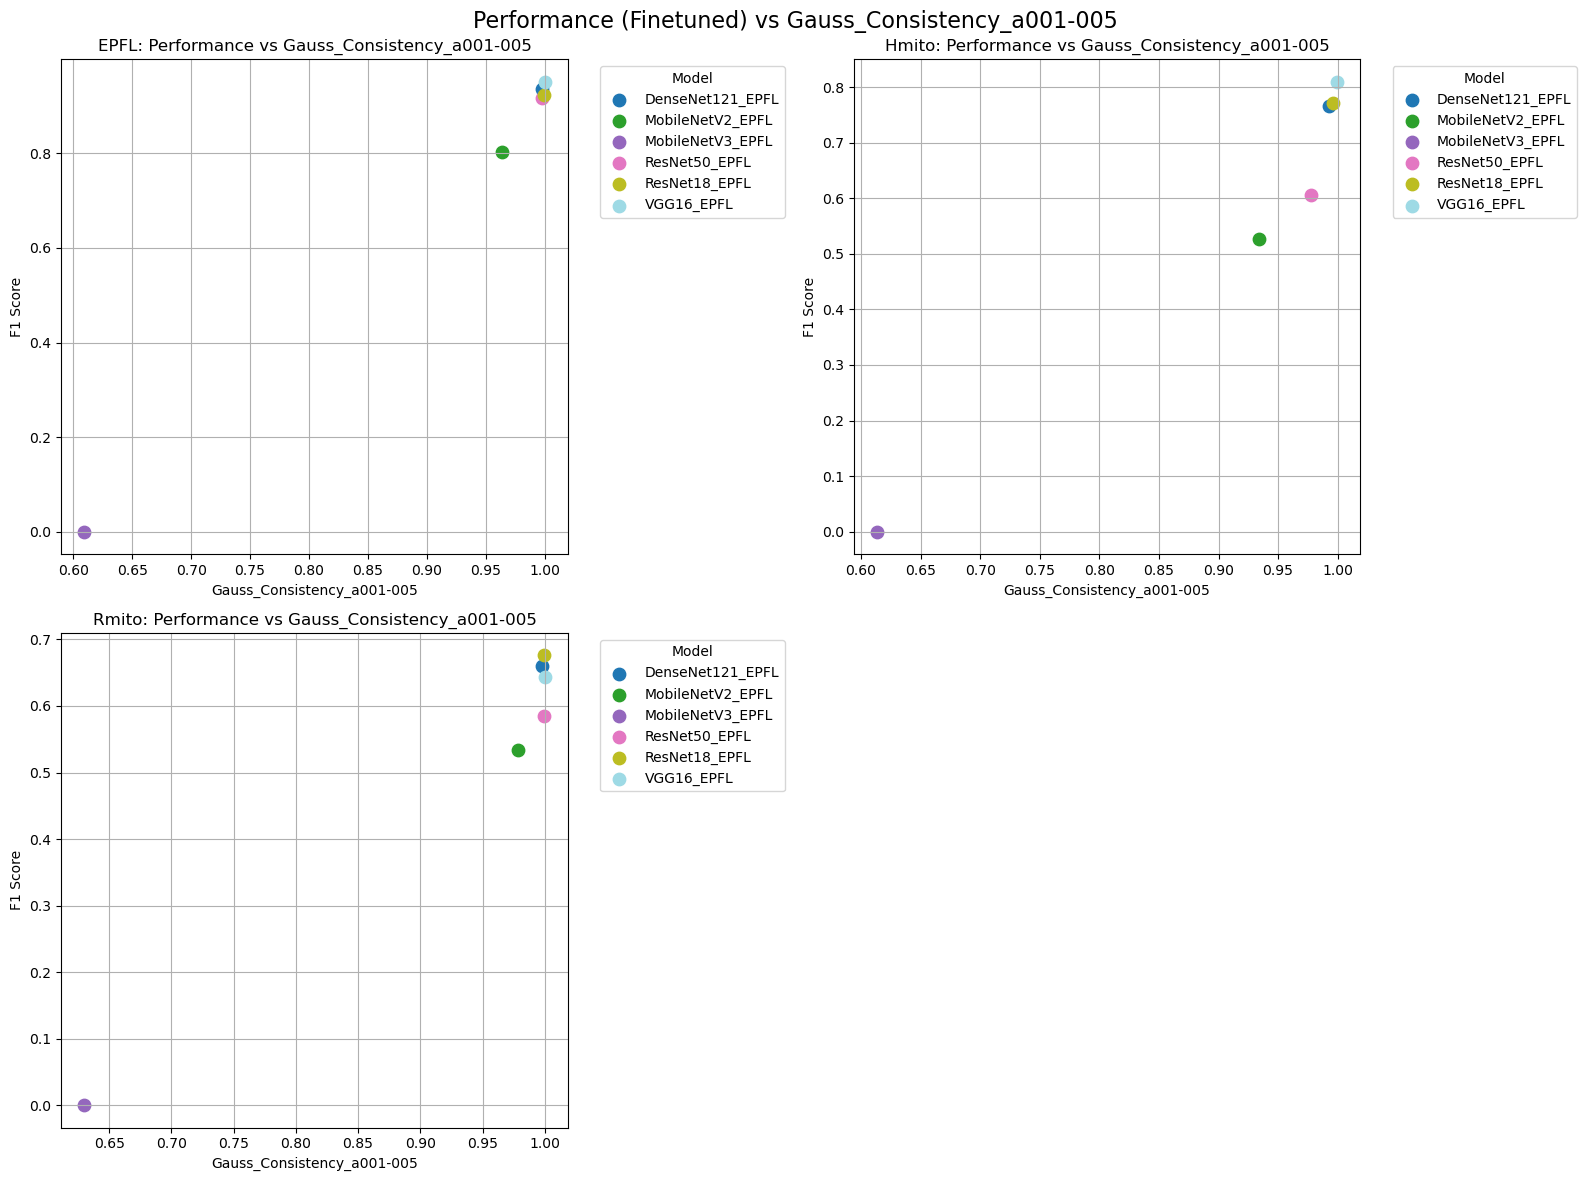

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     1.00      0.0   0.83        0.06  0.73     0.05
     Hmito    0.97      0.0   1.00        0.01  1.00     0.00
     Rmito    0.99      0.0   0.71        0.14  0.60     0.13
Processing: Gauss_Consistency_a005-01
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


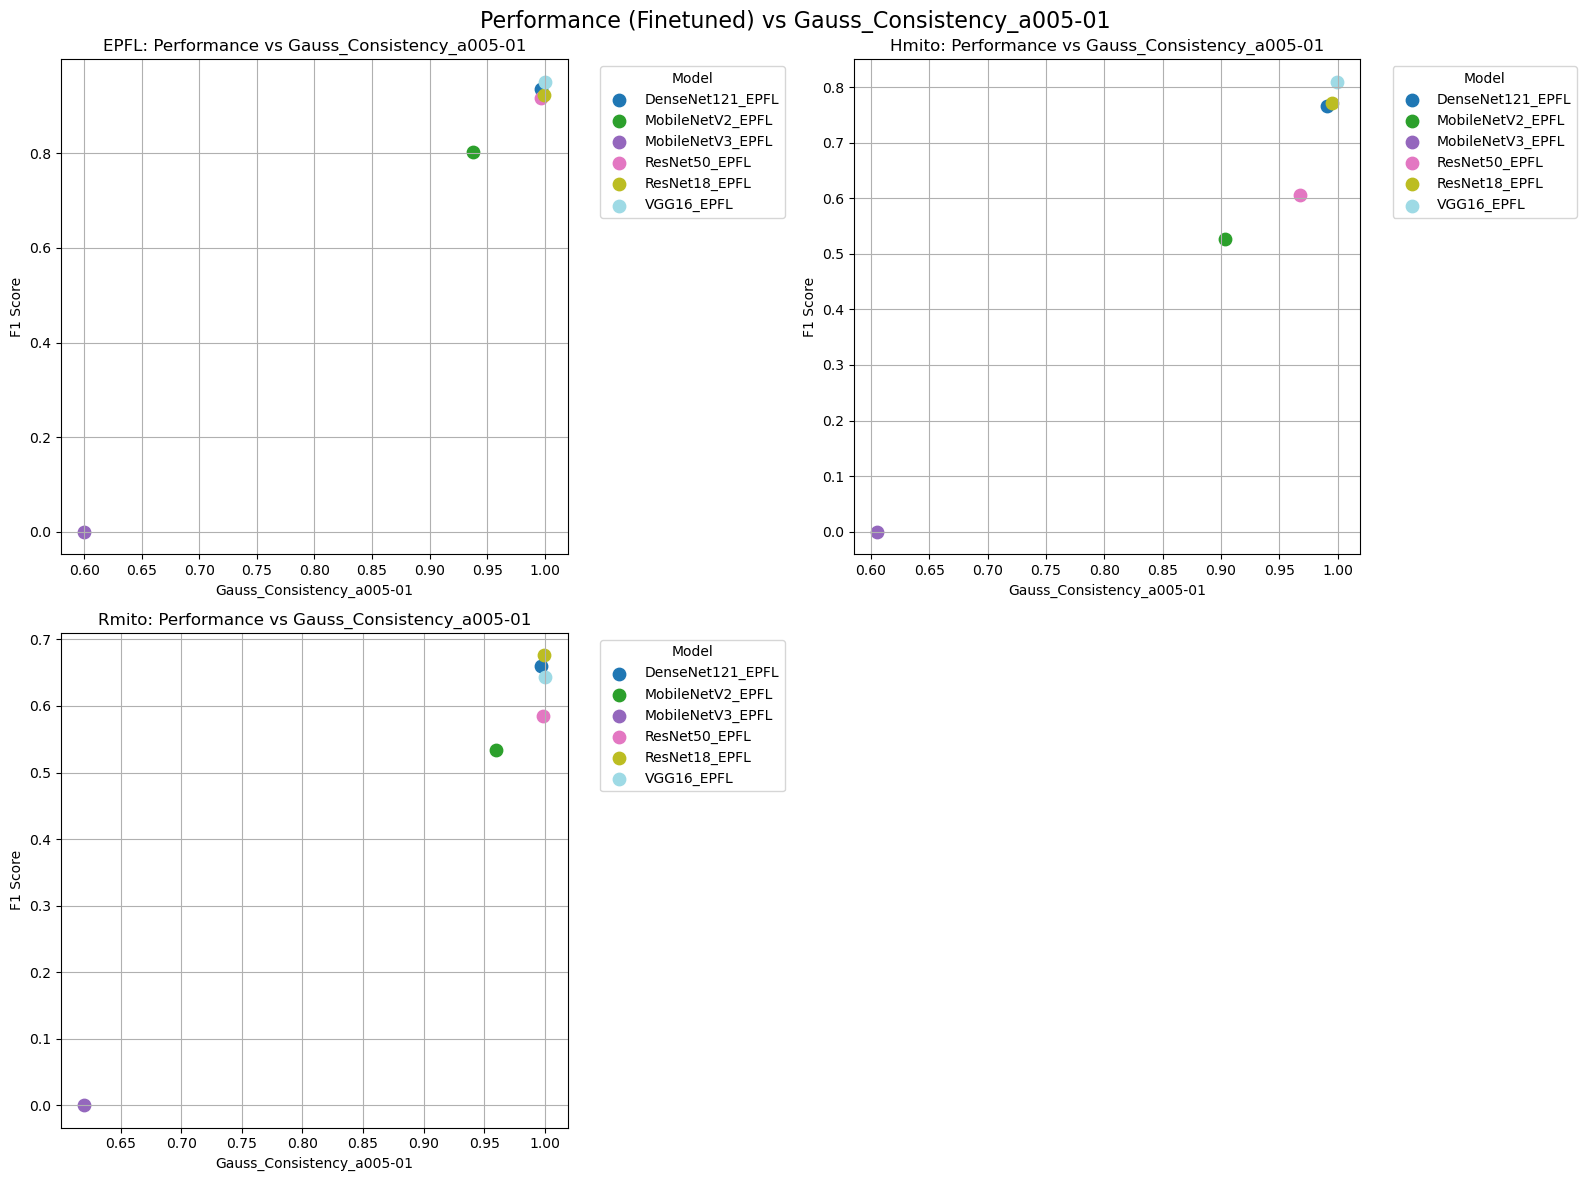

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     1.00      0.0   0.94        0.03  0.87     0.02
     Hmito    0.98      0.0   1.00        0.00  1.00     0.00
     Rmito    0.99      0.0   0.71        0.12  0.60     0.16
Processing: Gauss_Consistency_a01-015
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


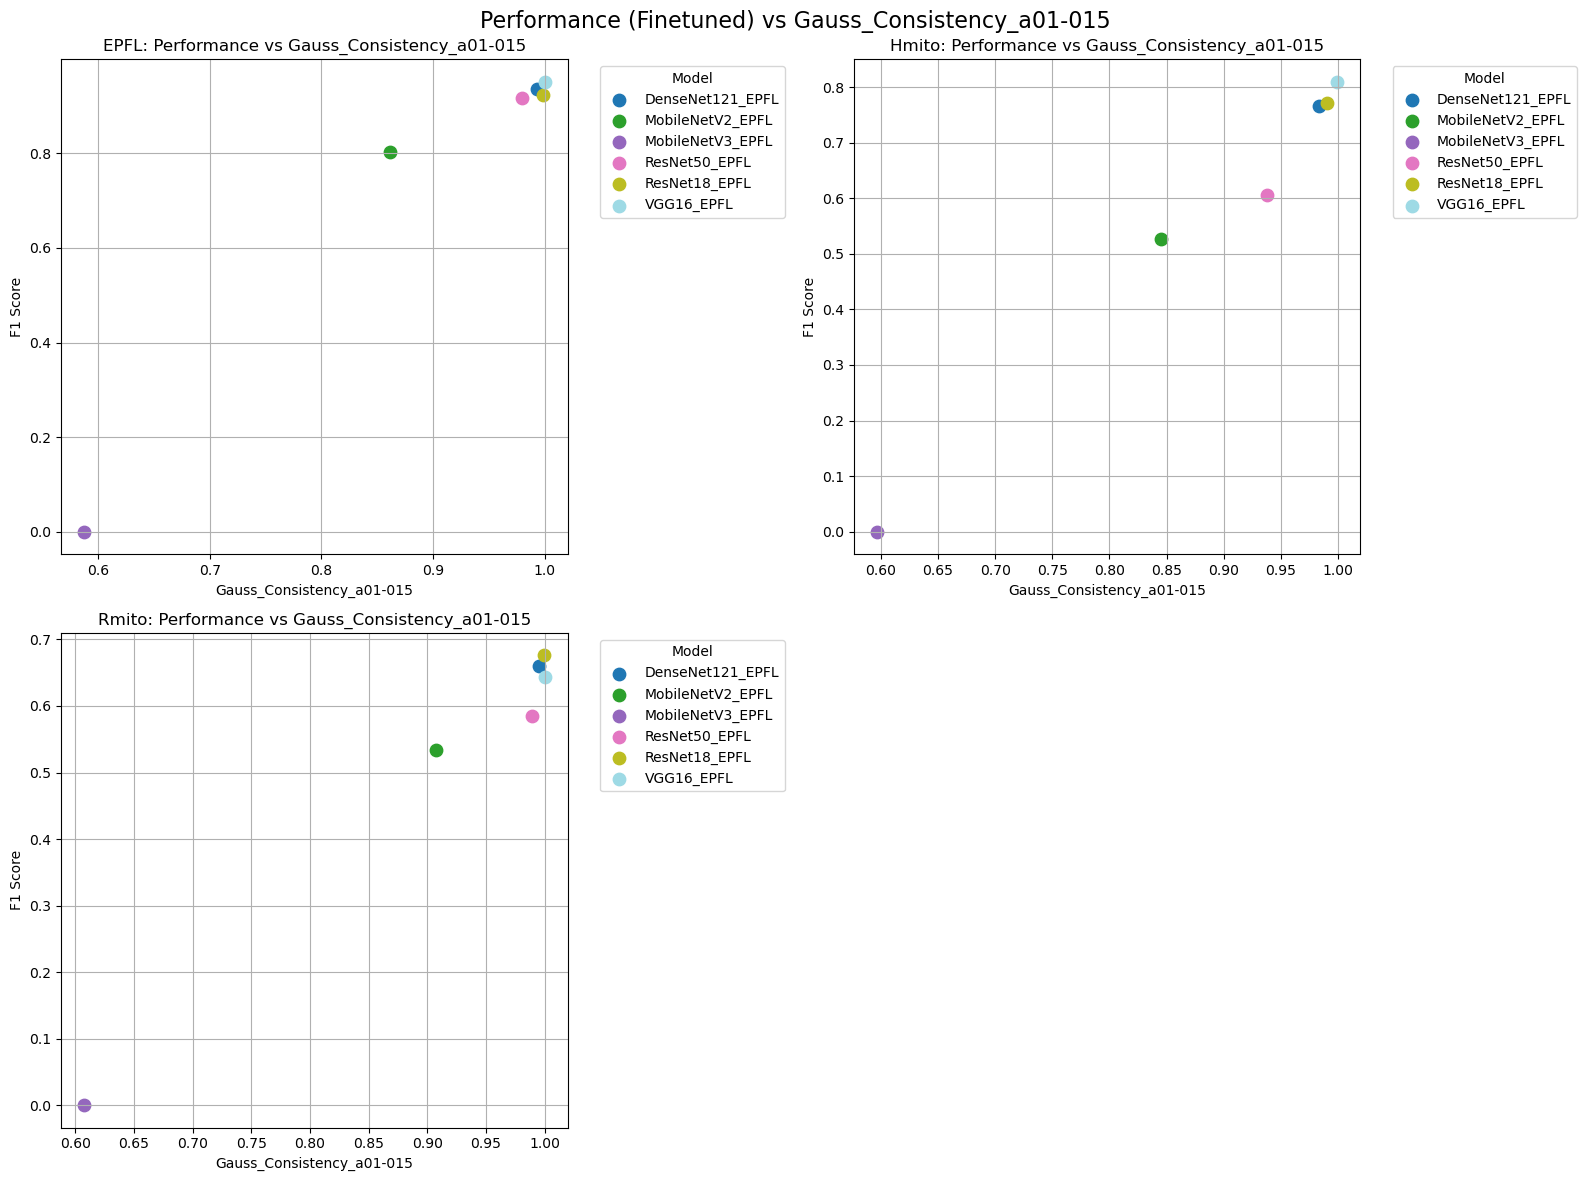

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.98      0.0   0.94        0.01  0.87     0.03
     Hmito    0.99      0.0   1.00        0.01  1.00     0.00
     Rmito    0.99      0.0   0.83        0.06  0.73     0.05
Processing: Gauss_Consistency_a015-02
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


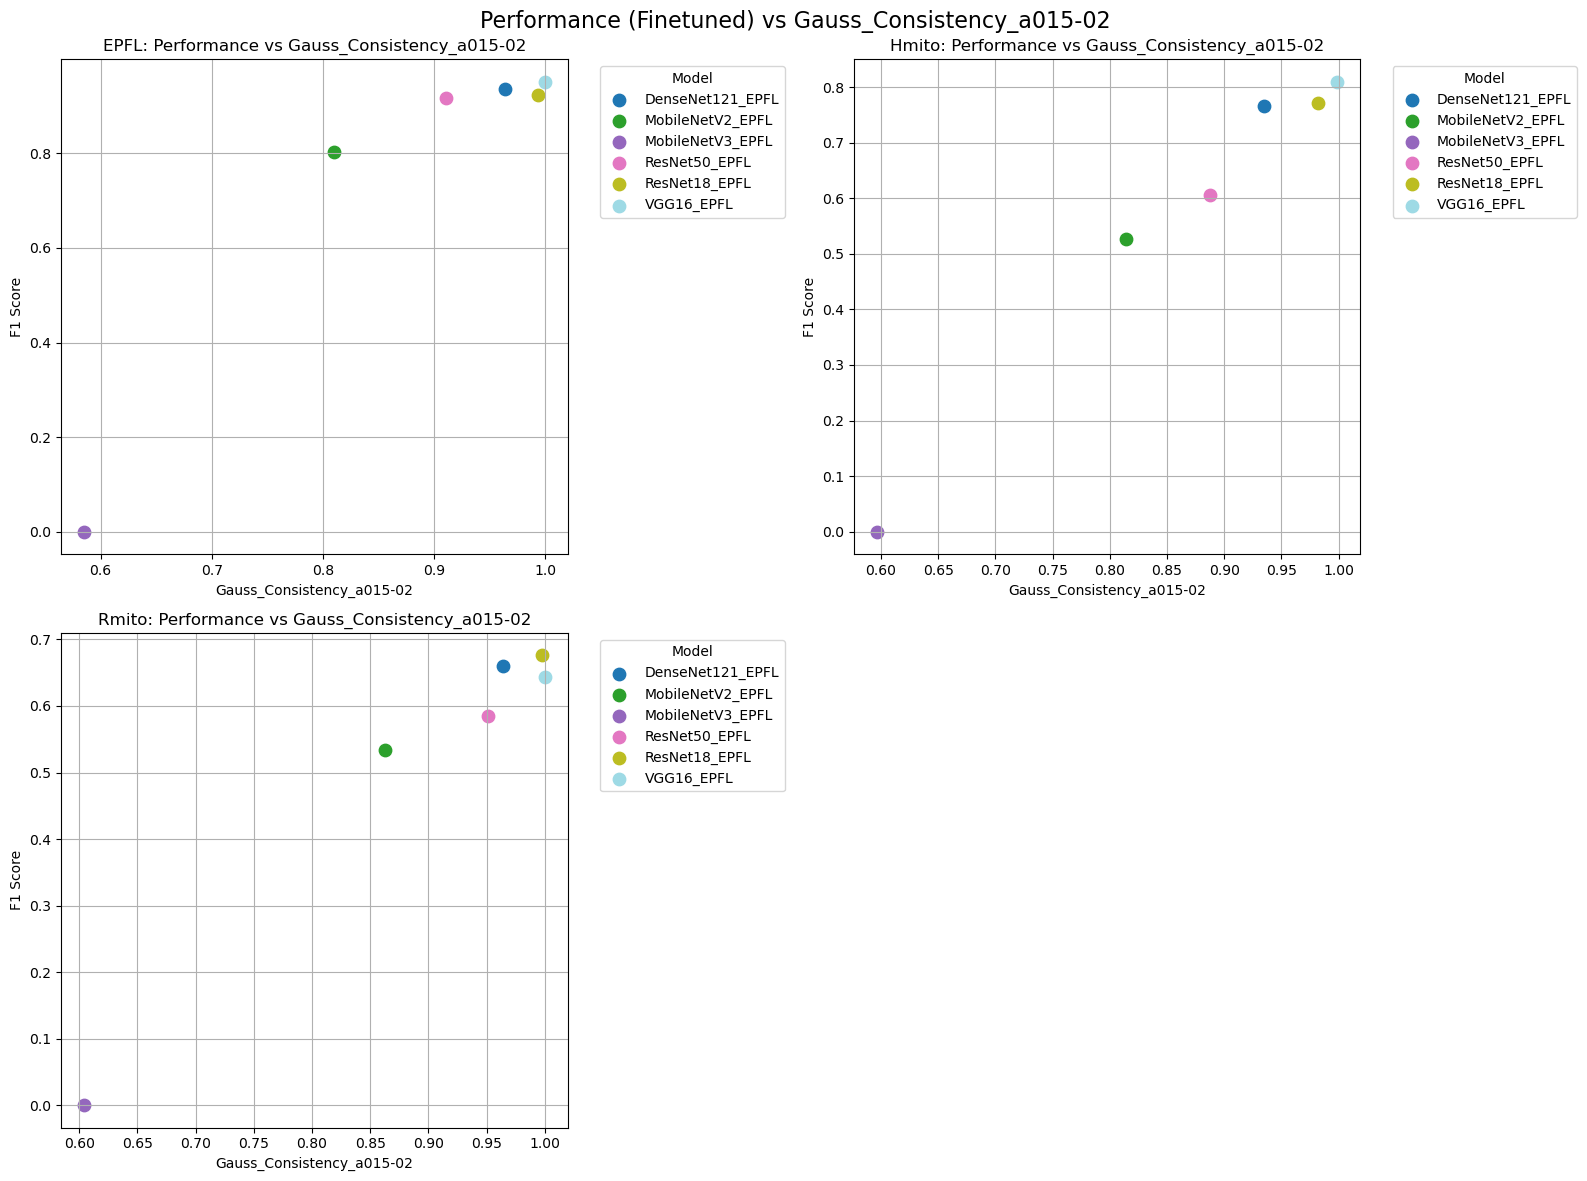

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.95      0.0   0.94        0.02  0.87     0.02
     Hmito    0.99      0.0   1.00        0.01  1.00     0.00
     Rmito    0.98      0.0   0.83        0.06  0.73     0.05
Processing: Gauss_Consistency_a02-025
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


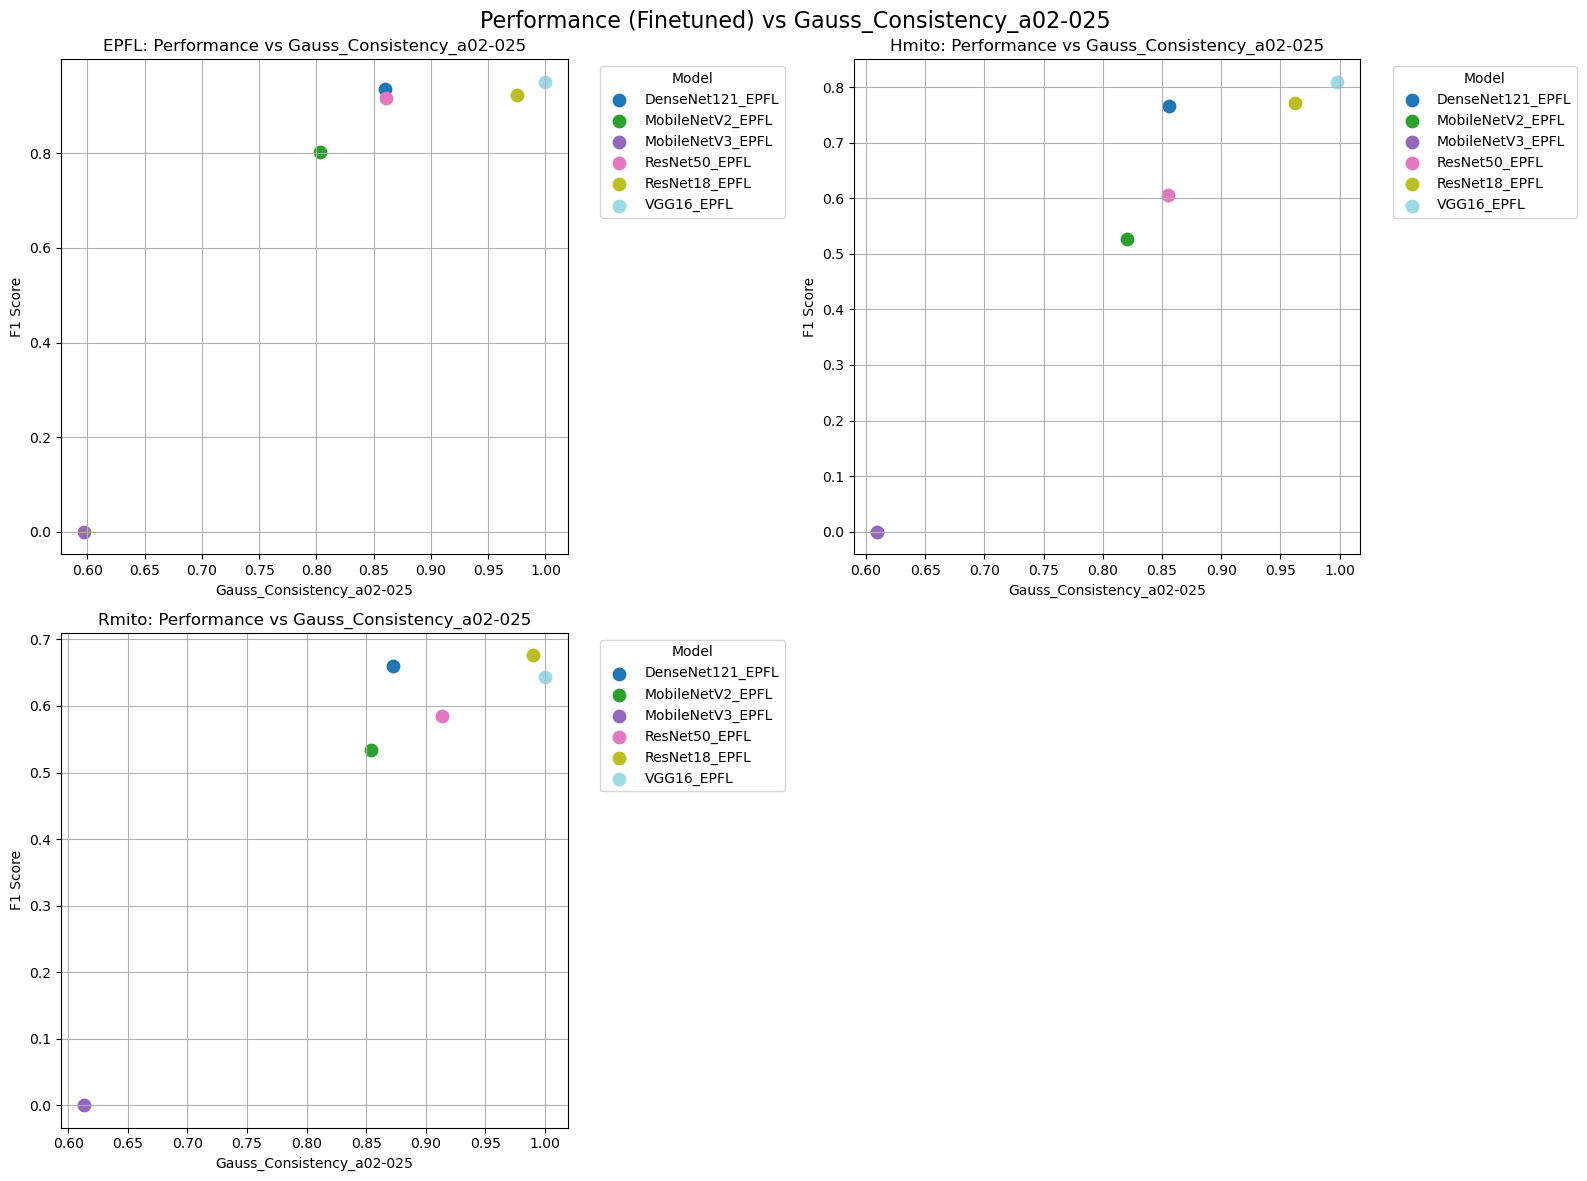

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.90     0.01   0.83        0.06  0.73     0.06
     Hmito    0.95     0.00   1.00        0.01  1.00     0.00
     Rmito    0.94     0.01   0.71        0.13  0.60     0.14


100%|██████████| 5/5 [00:00<00:00, 11.57it/s]


Processing: Gauss_Consistency_a001-005
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


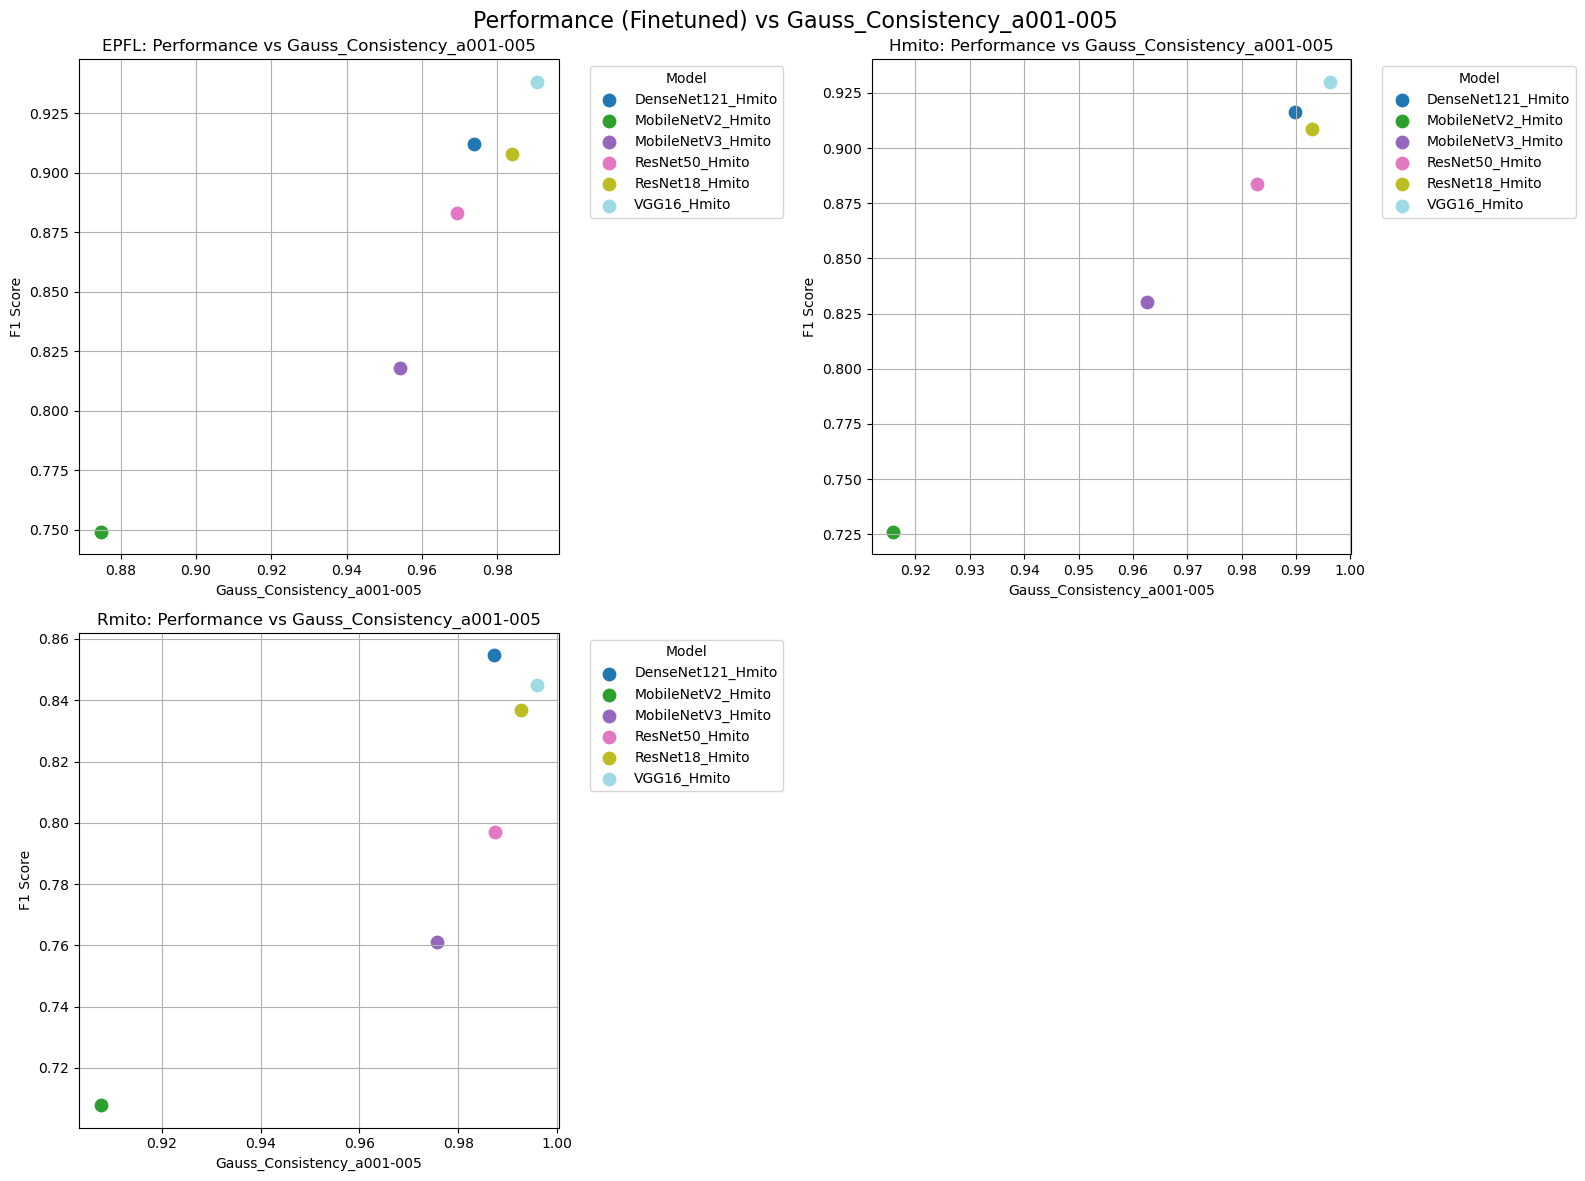

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.94     0.00   0.94        0.01  0.87     0.03
     Hmito    1.00     0.00   0.94        0.01  0.87     0.03
     Rmito    0.88     0.02   0.66        0.20  0.60     0.13
Processing: Gauss_Consistency_a005-01
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


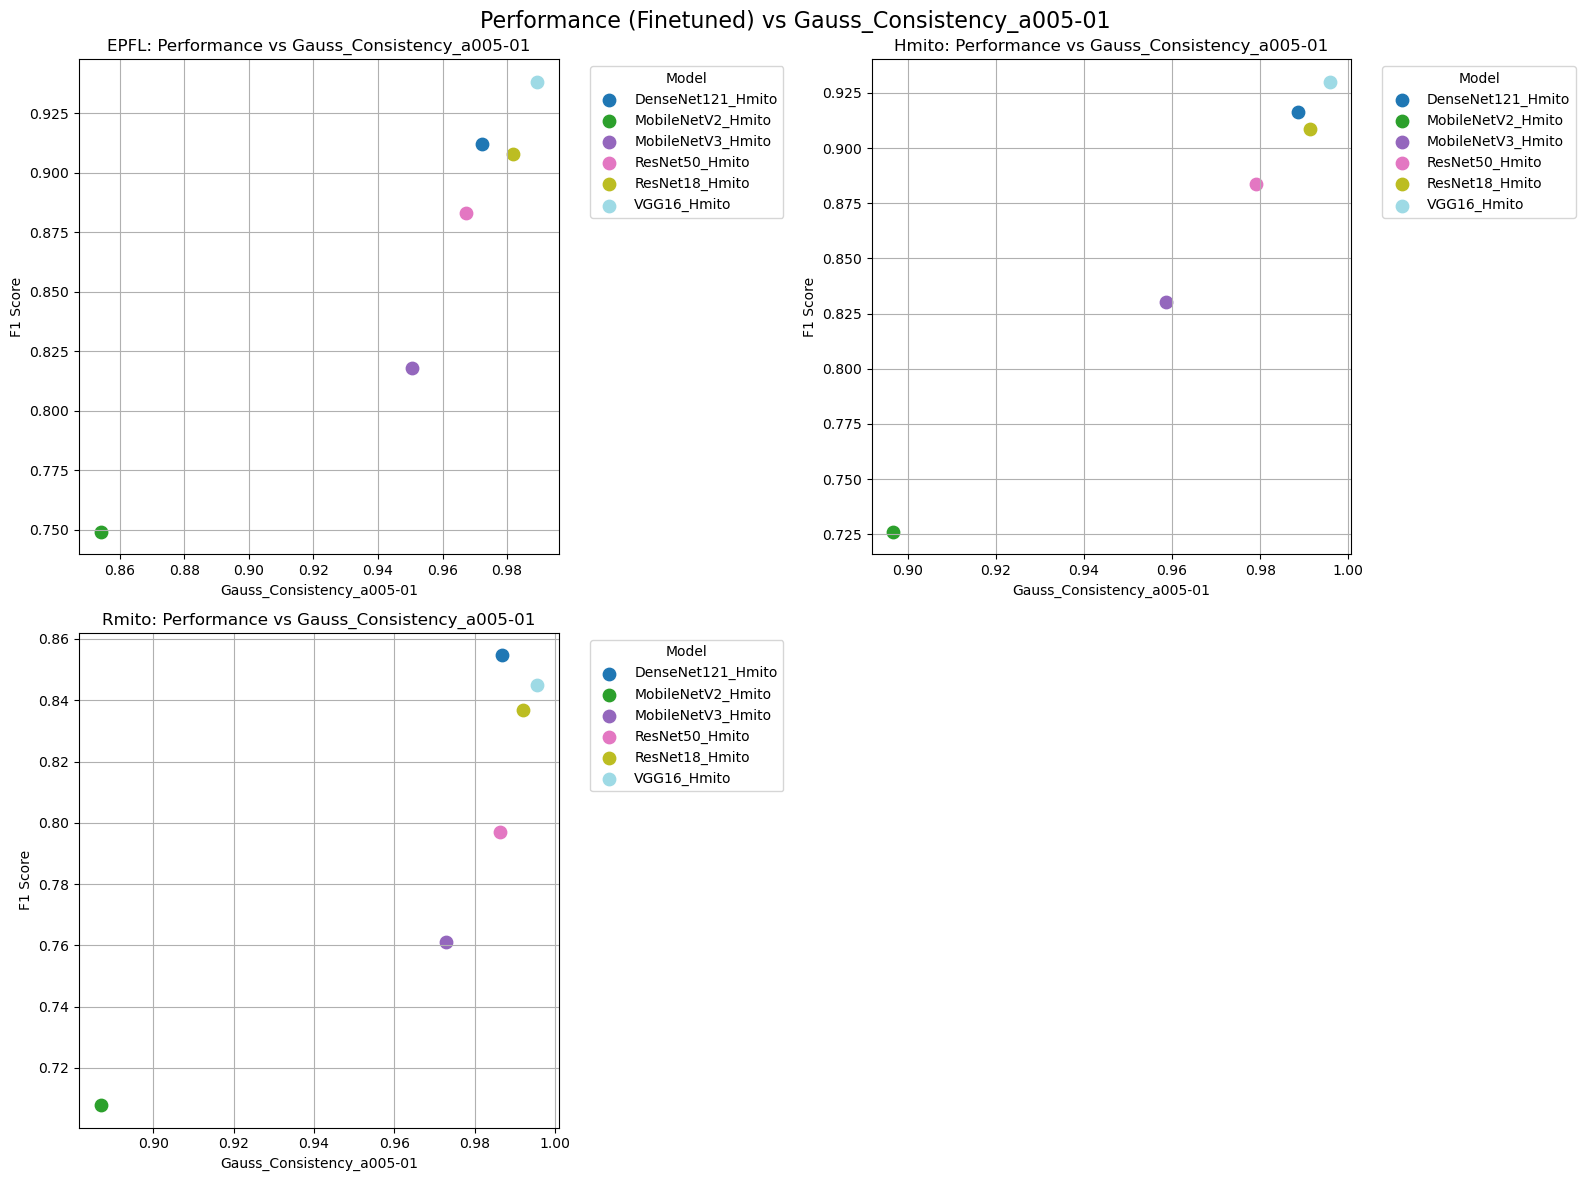

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.93     0.01   0.94        0.02  0.87     0.01
     Hmito    0.99     0.00   0.94        0.02  0.87     0.01
     Rmito    0.87     0.02   0.83        0.07  0.73     0.06
Processing: Gauss_Consistency_a01-015
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


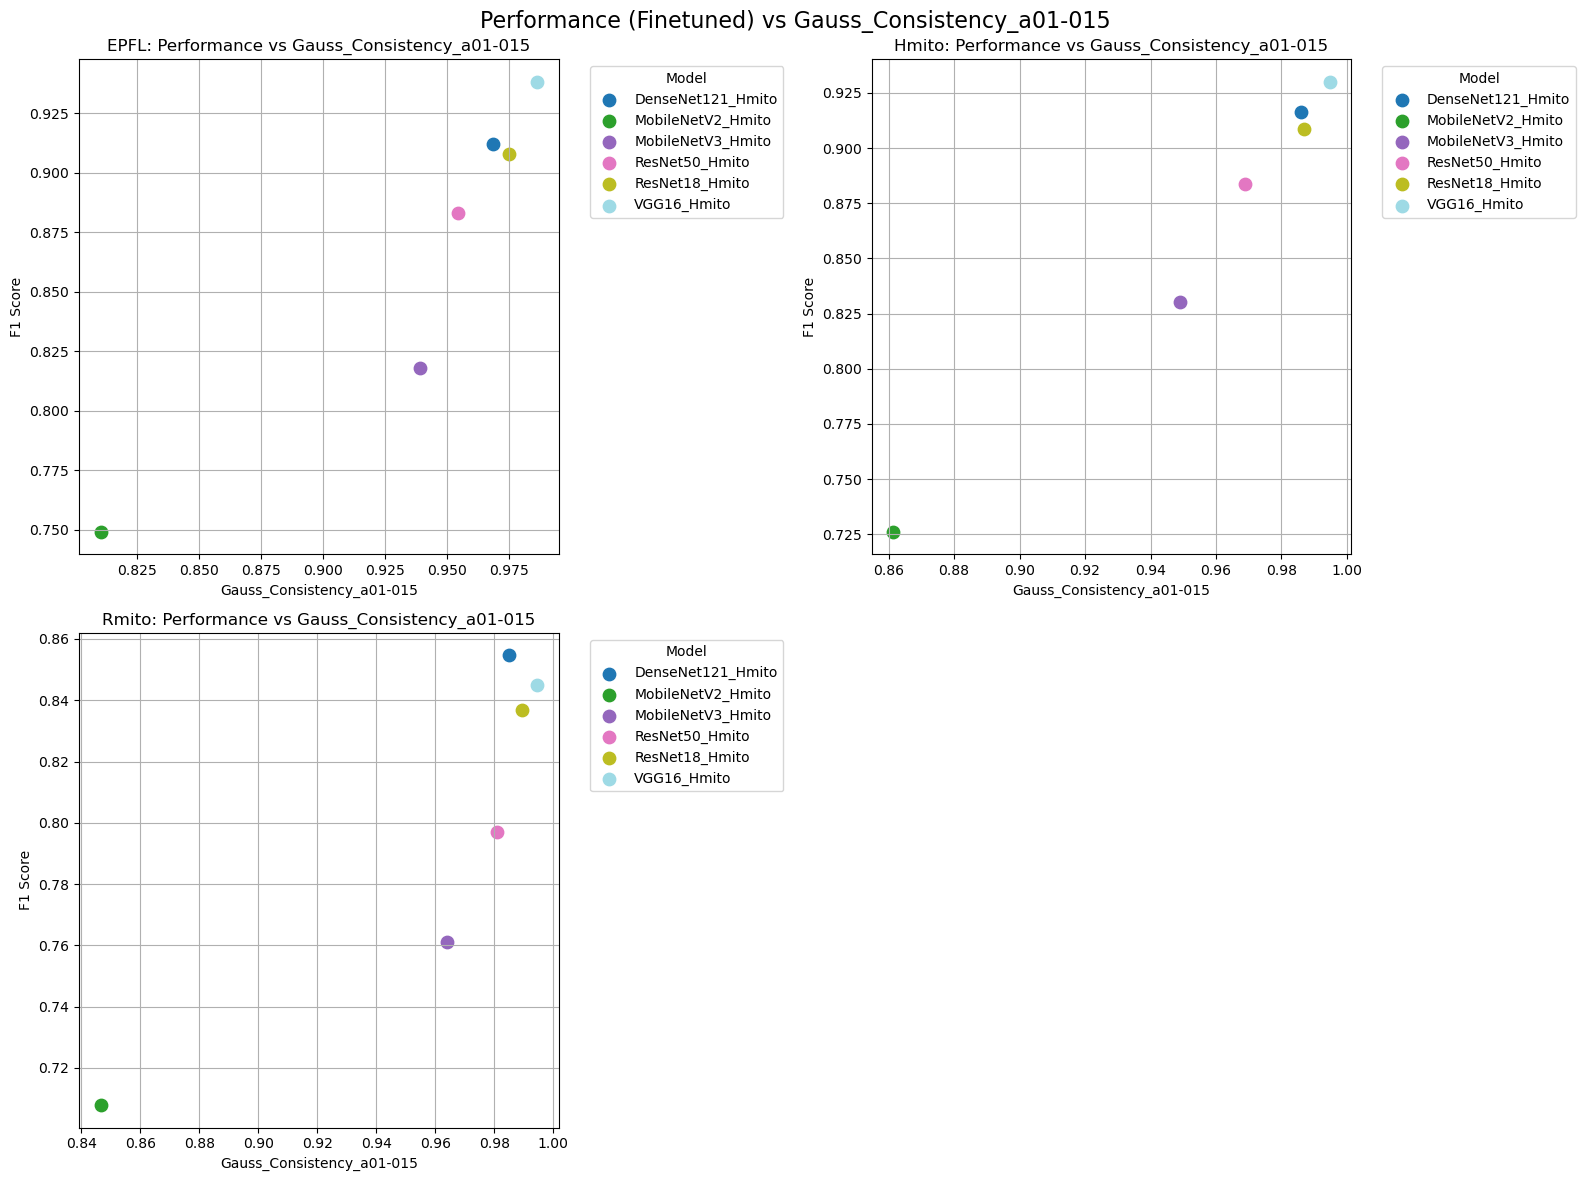

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.93     0.01   0.94        0.03  0.87     0.02
     Hmito    0.99     0.00   0.94        0.02  0.87     0.02
     Rmito    0.88     0.02   0.83        0.07  0.73     0.05
Processing: Gauss_Consistency_a015-02
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


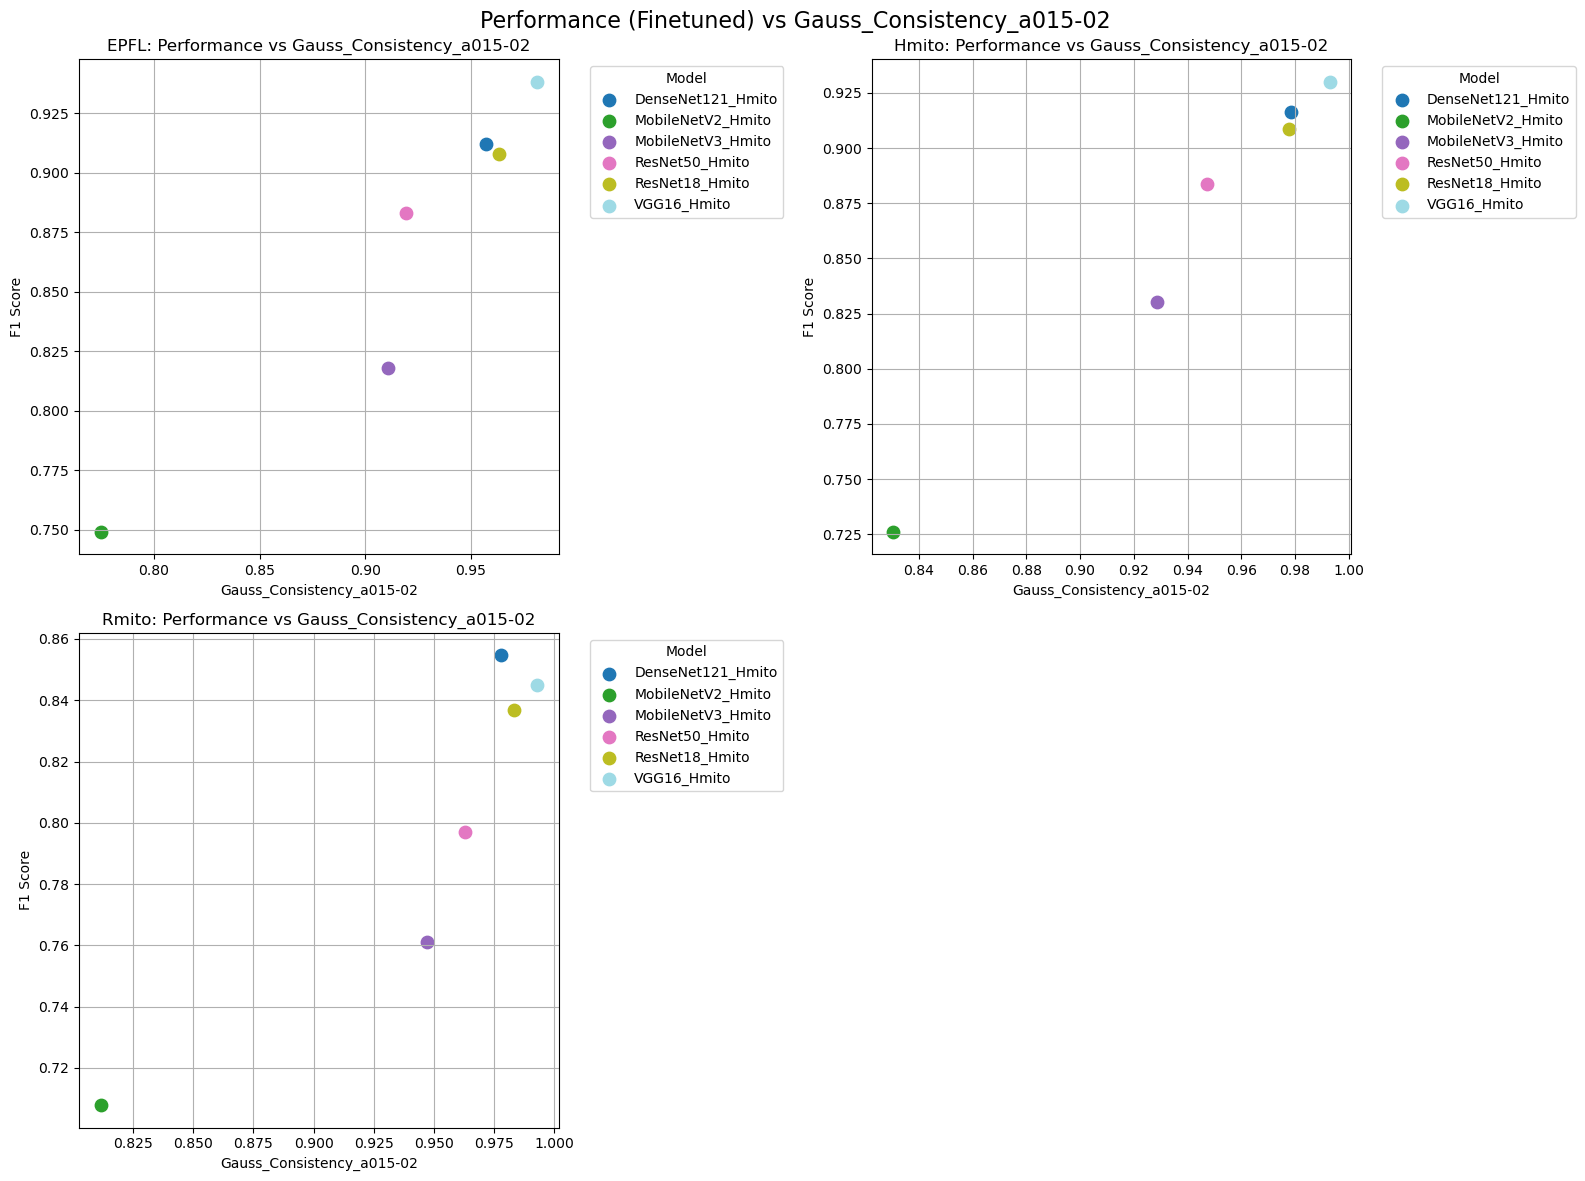

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.95     0.00   0.94        0.01  0.87     0.01
     Hmito    0.99     0.00   1.00        0.01  1.00     0.01
     Rmito    0.90     0.01   0.83        0.06  0.73     0.05
Processing: Gauss_Consistency_a02-025
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


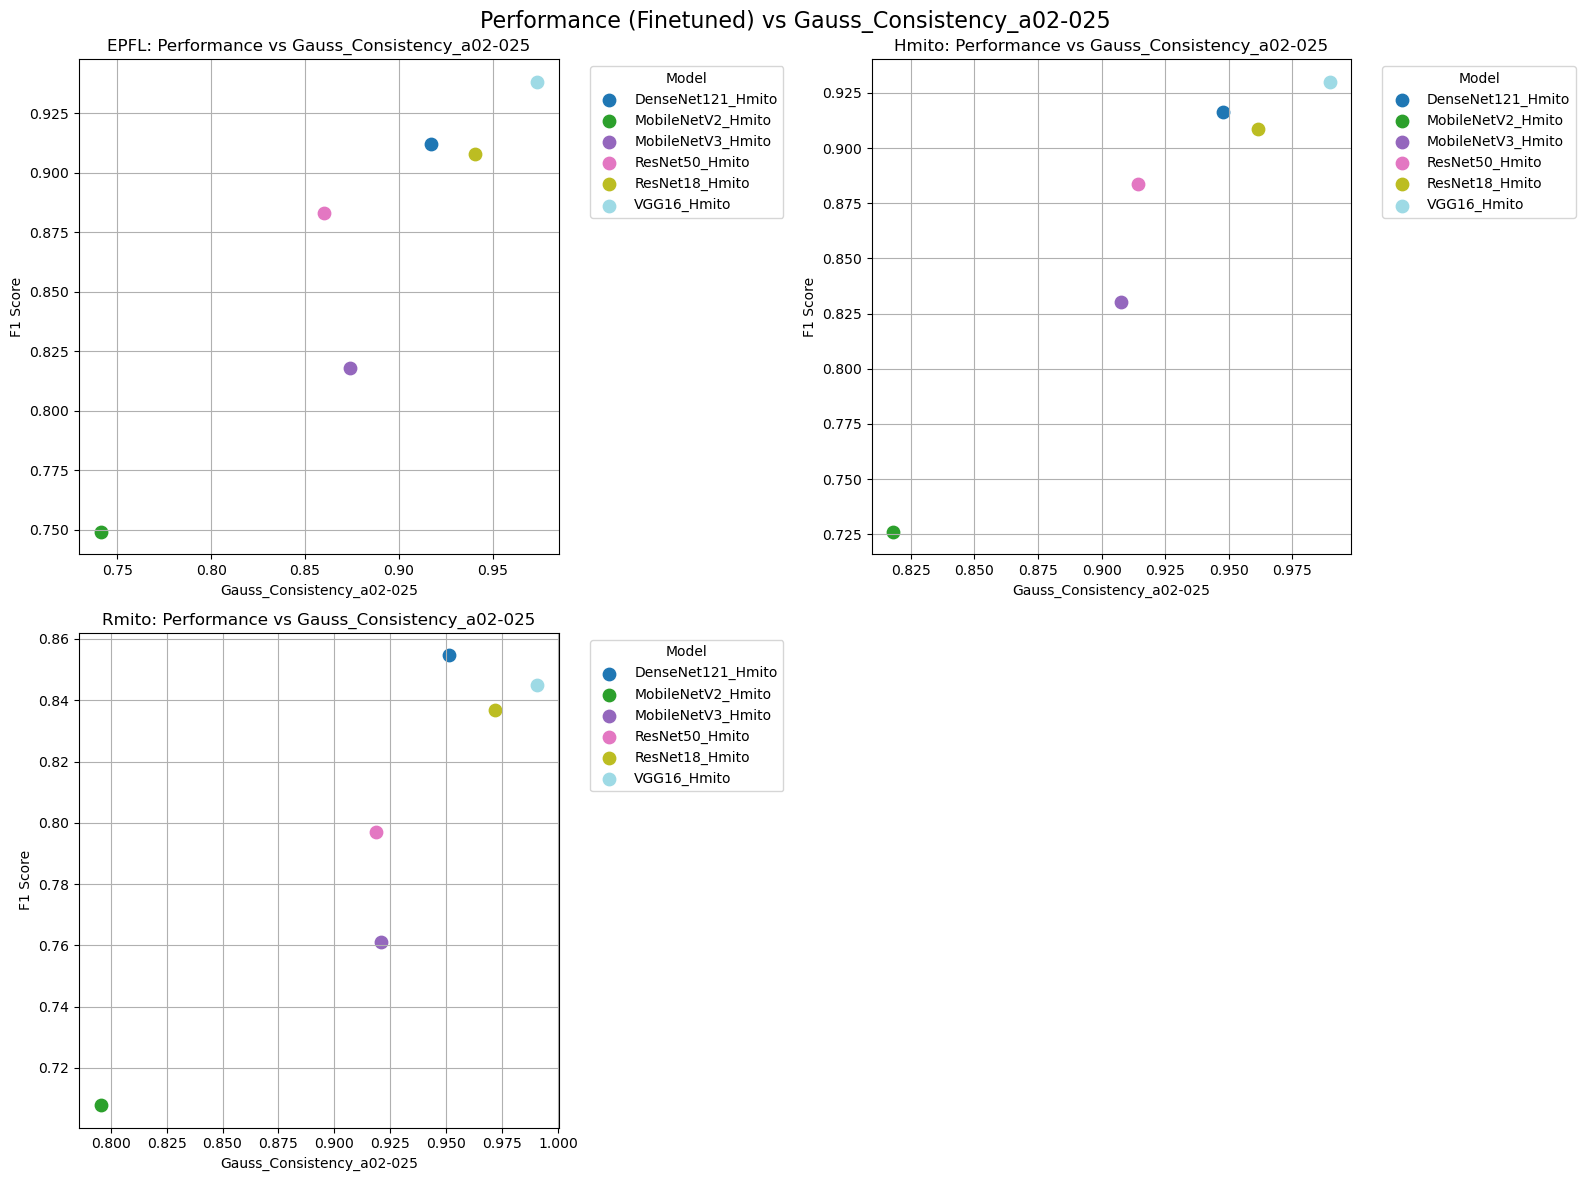

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.93     0.01   0.89        0.05  0.73     0.06
     Hmito    0.97     0.00   0.94        0.01  0.87     0.01
     Rmito    0.92     0.01   0.77        0.10  0.60     0.15


100%|██████████| 5/5 [00:00<00:00, 12.87it/s]


Processing: Gauss_Consistency_a001-005
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


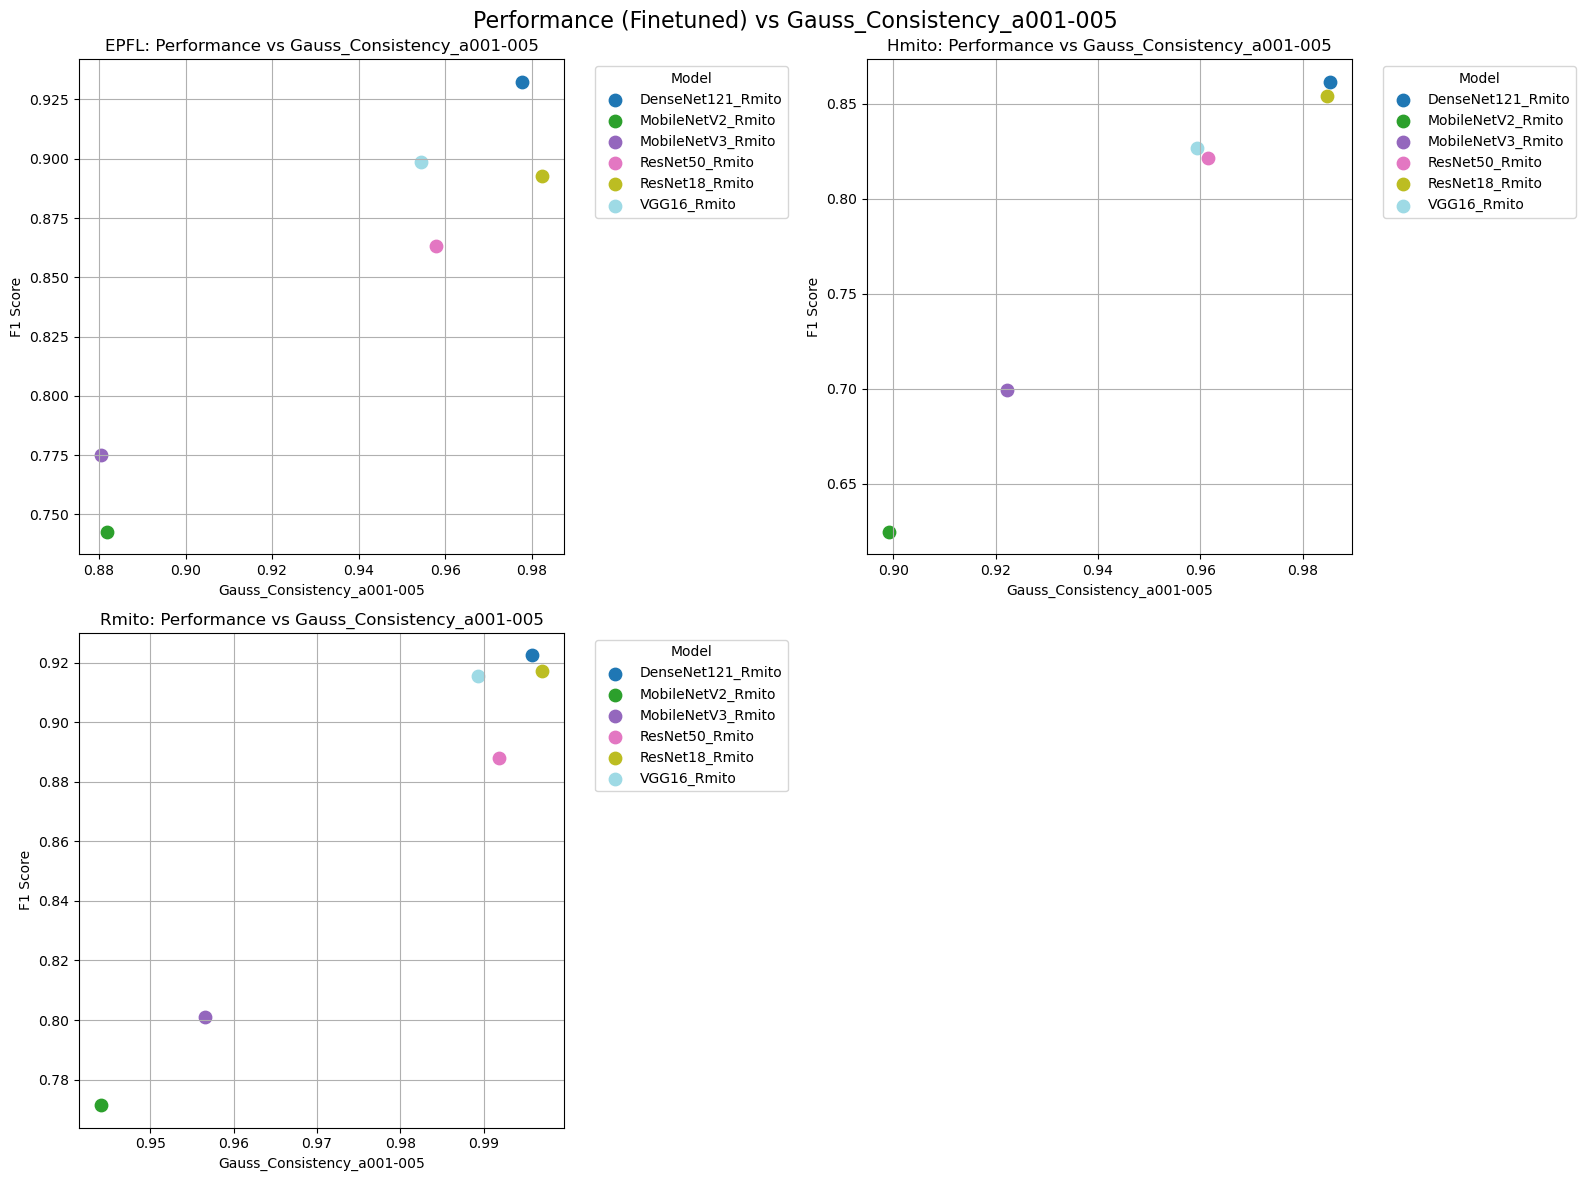

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.95      0.0   0.66        0.17  0.47     0.27
     Hmito    0.99      0.0   0.94        0.03  0.87     0.02
     Rmito    0.98      0.0   0.89        0.02  0.73     0.05
Processing: Gauss_Consistency_a005-01
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


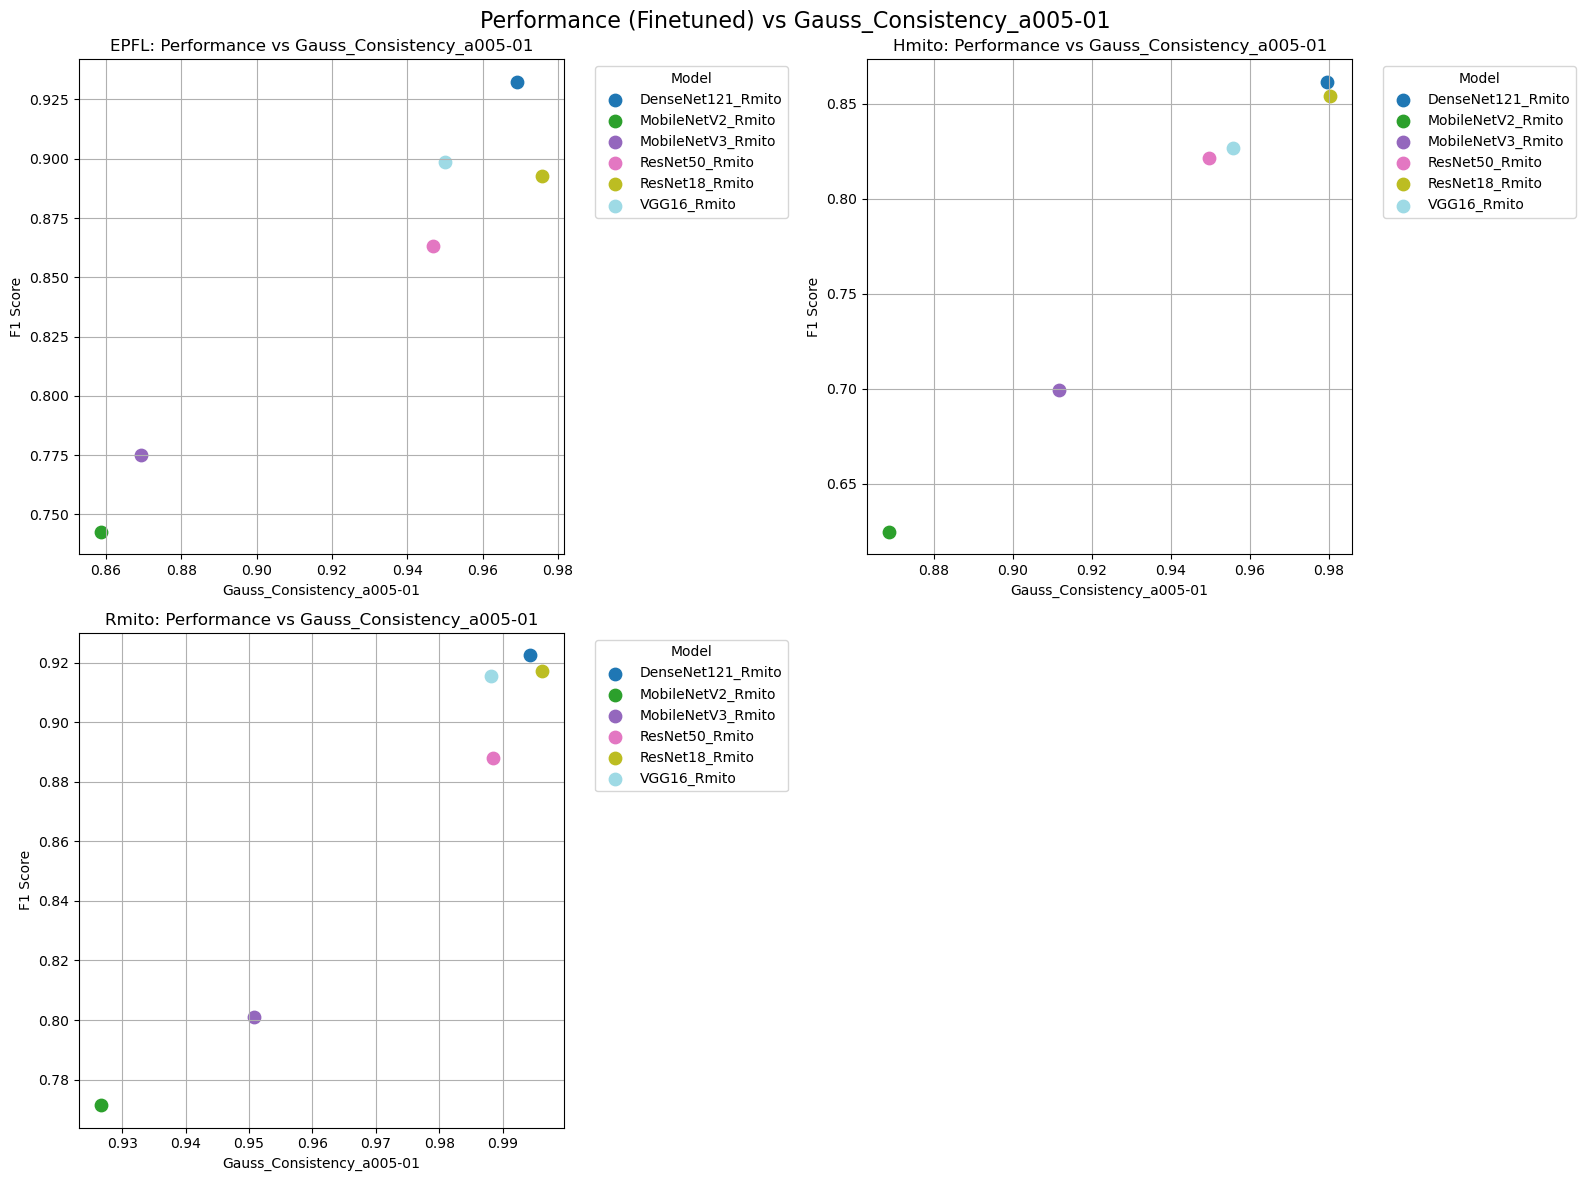

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.97      0.0   0.83        0.06  0.73     0.06
     Hmito    0.99      0.0   0.94        0.02  0.87     0.02
     Rmito    0.98      0.0   0.89        0.04  0.73     0.05
Processing: Gauss_Consistency_a01-015
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


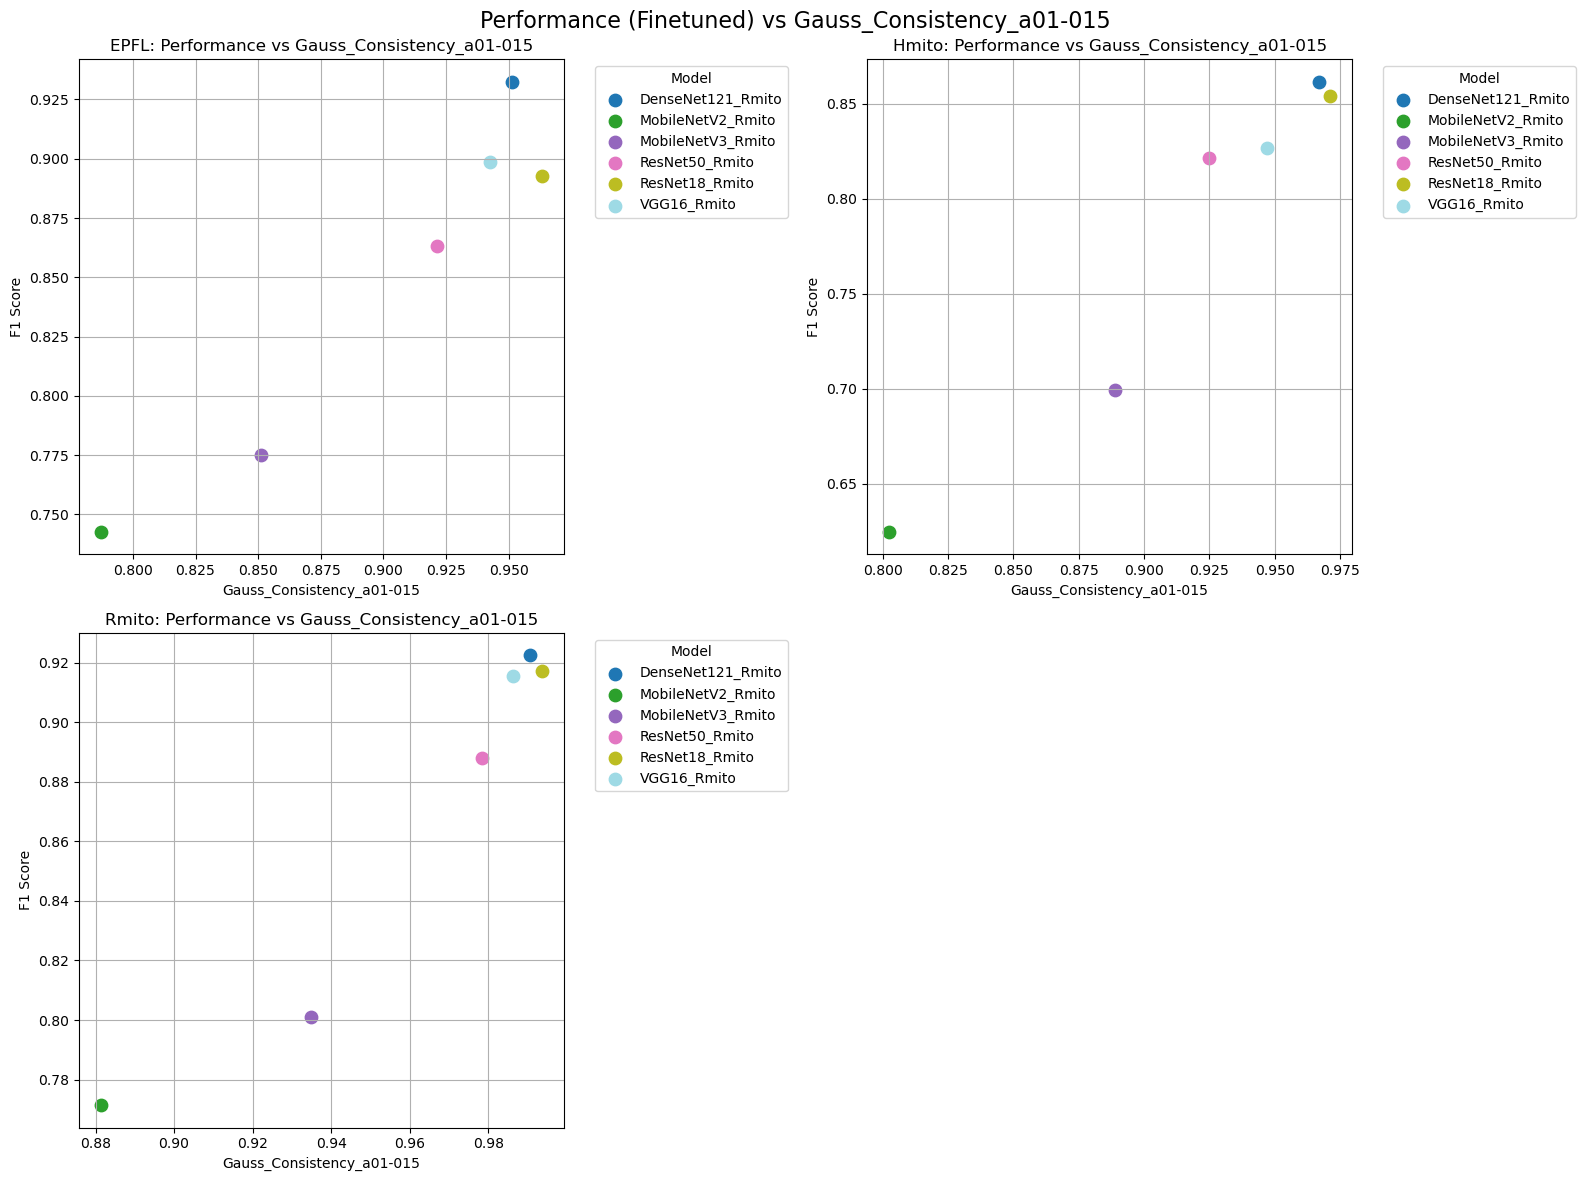

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.96      0.0   0.83        0.07  0.73     0.04
     Hmito    0.97      0.0   0.94        0.02  0.87     0.02
     Rmito    0.97      0.0   0.94        0.03  0.87     0.02
Processing: Gauss_Consistency_a015-02
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


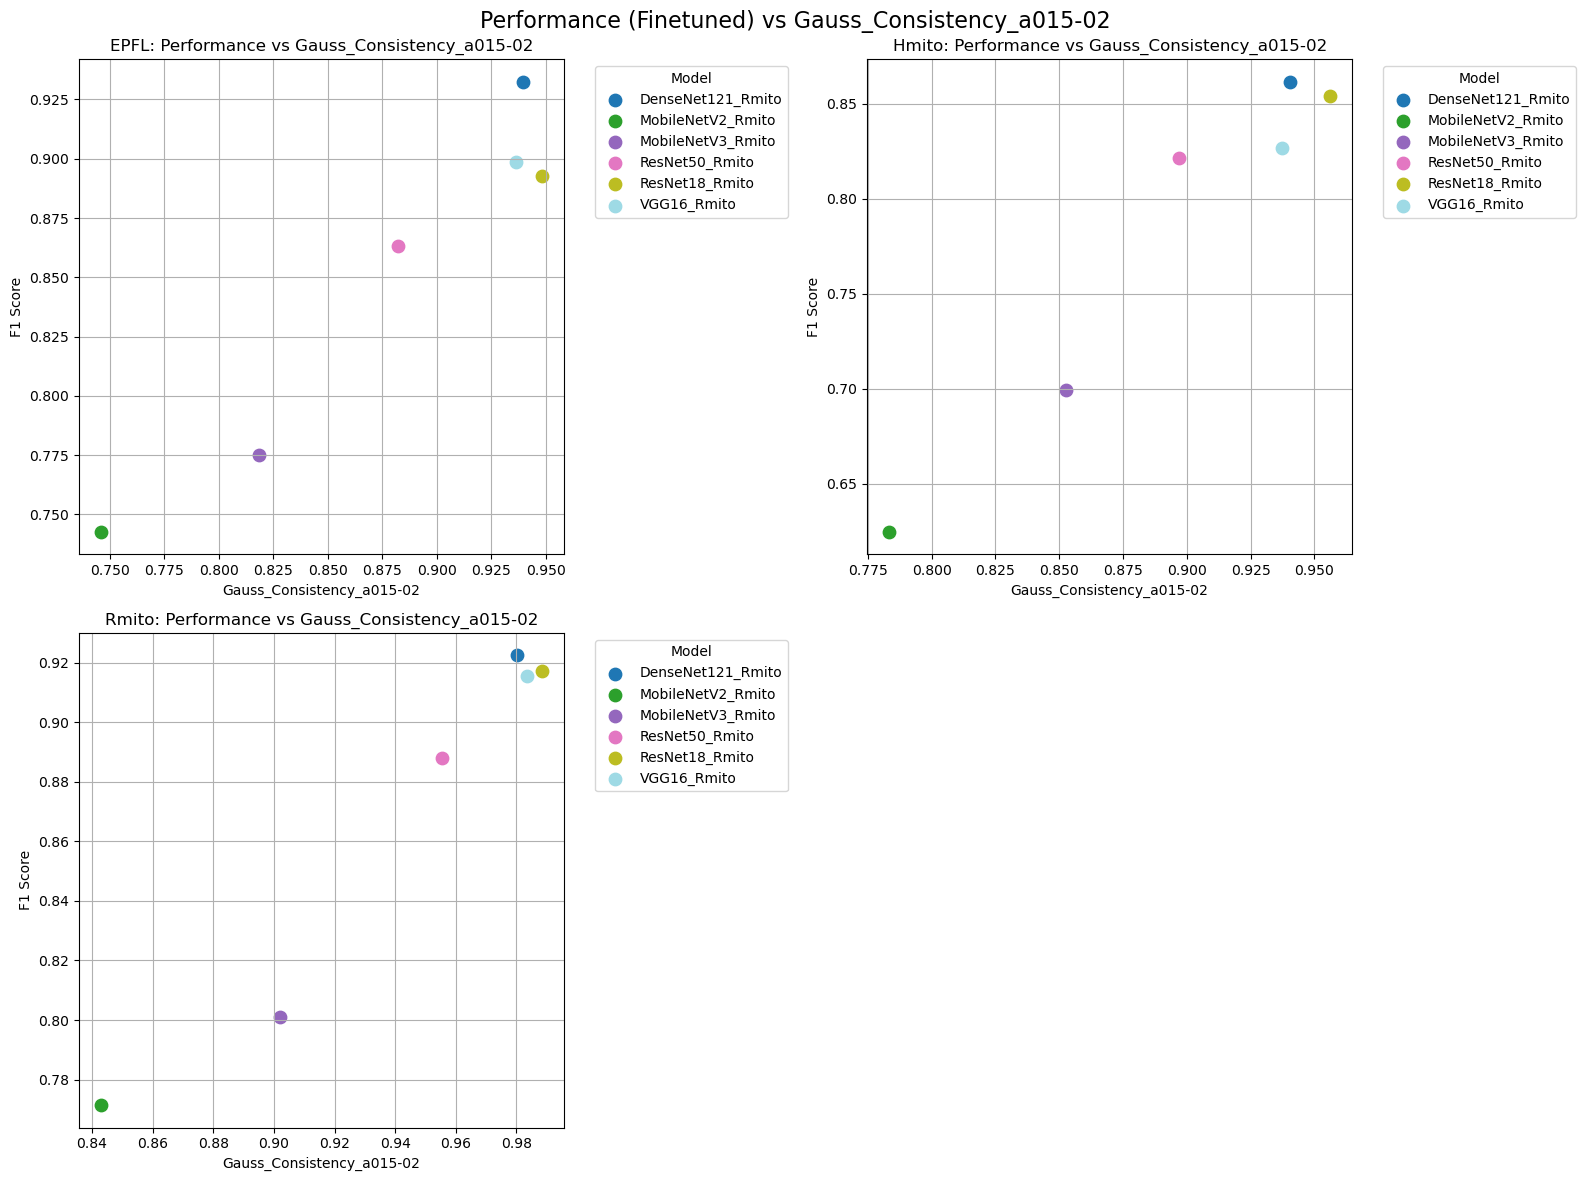

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.97      0.0   0.83        0.06  0.73     0.07
     Hmito    0.97      0.0   0.94        0.03  0.87     0.01
     Rmito    0.98      0.0   0.83        0.06  0.73     0.05
Processing: Gauss_Consistency_a02-025
Number of targets: 3
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito


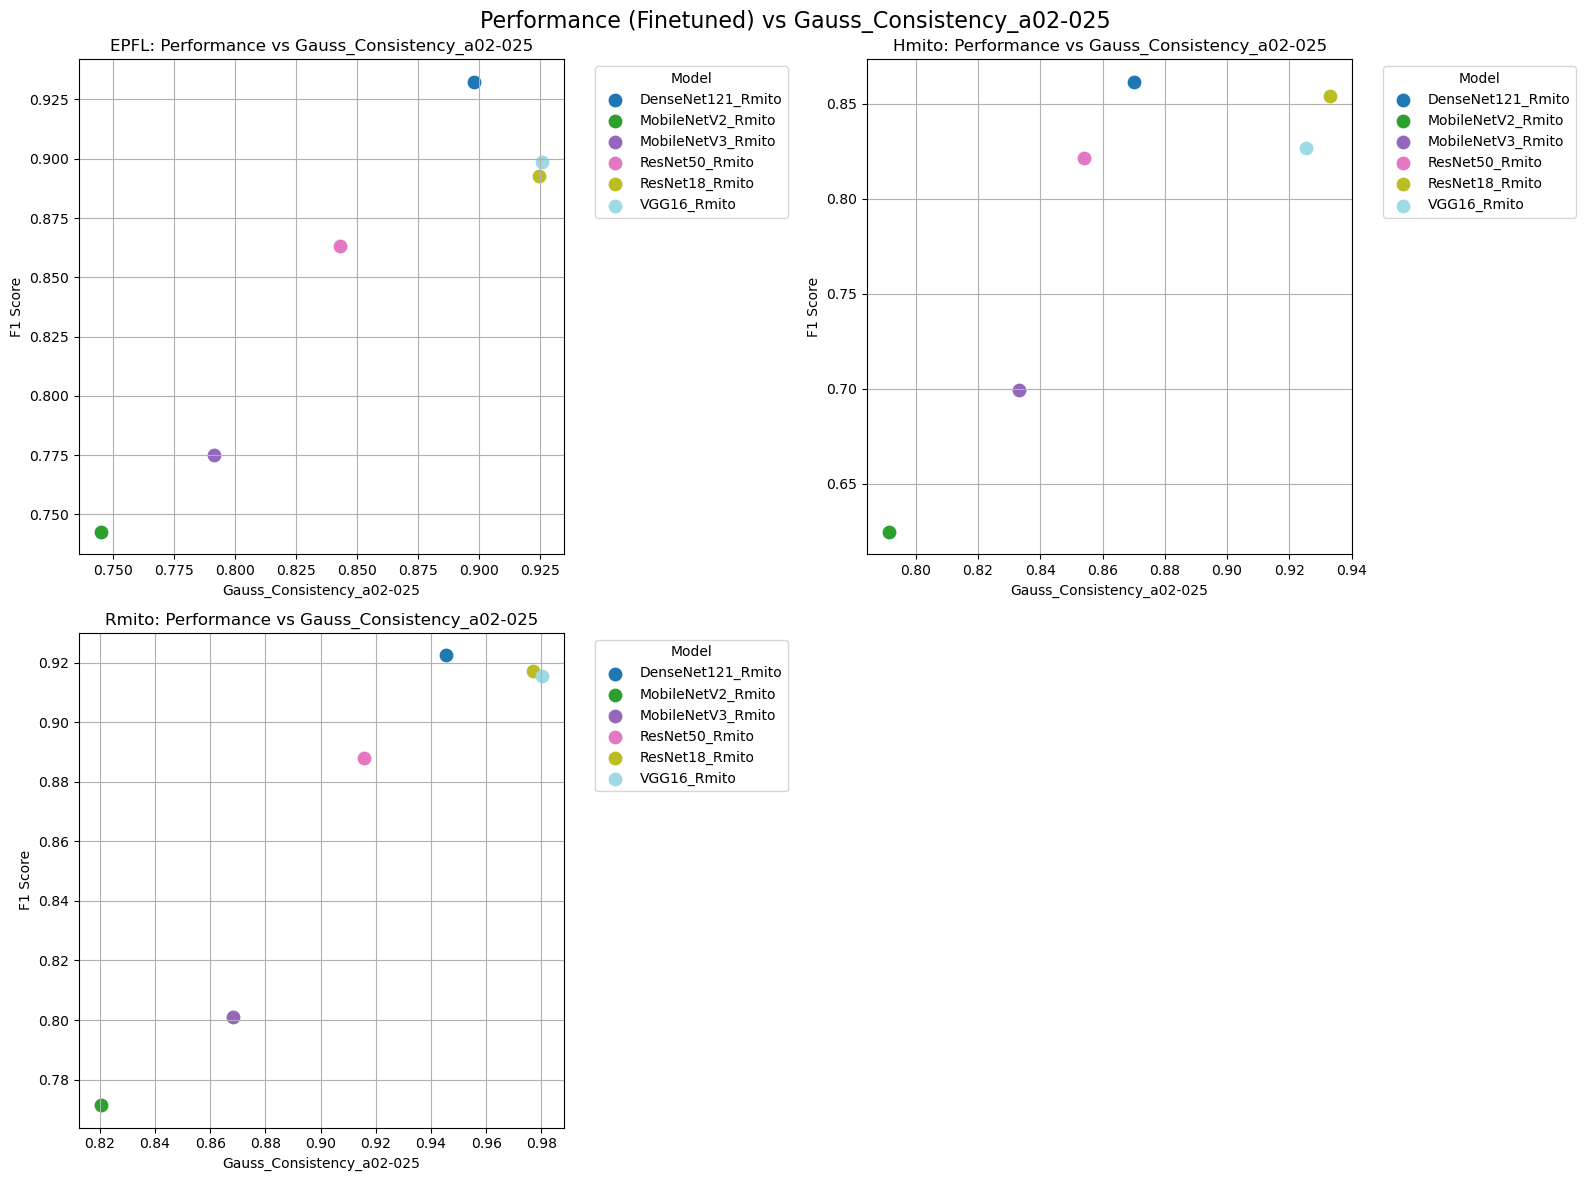

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.94     0.01   0.83        0.05  0.73     0.06
     Hmito    0.83     0.04   0.83        0.06  0.73     0.04
     Rmito    0.96     0.00   0.77        0.11  0.60     0.15


In [4]:
#models: List[str] = []
for source in sources:
    models = [f"{model}_{source}" for model in source_models]
    cfg = ClassificationPredicitonLoadConfig(
        source=models,
        target=targets,
        base_path=base_path,
        perturbations=perturbations,
    )
    consis_results = get_classification_consistency_results(cfg, consis_key)
    performance_results = get_classification_performance_results(cfg, performance_key)

    for p_str in perturbations["Gauss"]:
        consis_scores = consis_results["Gauss"][p_str]
        plot_performance_vs_transfer_metric_multi_target(
            performance_scores=performance_results,
            transfer_scores=consis_scores,
            transfer_metric=f"Gauss_Consistency_{p_str}",
            finetuned= True
        )
        KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
            targets=targets,
            transfer_metric_per_target=consis_scores,
            performance_per_target=performance_results,
        )
        correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
        print(correlation_df)